# 01 - CV Transformer Core Workflow


In [1]:
# Requires: pip install -e .

import importlib
import itertools
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch_geometric.utils import to_dense_batch

from graph_utils import calc_p_ratio_box, calc_p_ratio_rollout_sides, draw_graph, pyg_to_networkx

import course_project.config as config_mod
import course_project.graph as graph_mod
import course_project.metrics as metrics_mod
import course_project.models.components as components_mod
import course_project.models.cv_core as cv_core_mod
import course_project.models.cv_transformer_simulator as cv_transformer_simulator_mod
import course_project.models.linear_cv_simulator as linear_cv_simulator_mod
import course_project.models as models_mod
import course_project.runner as runner_mod

for module in [
    config_mod,
    graph_mod,
    metrics_mod,
    components_mod,
    cv_core_mod,
    cv_transformer_simulator_mod,
    linear_cv_simulator_mod,
    models_mod,
    runner_mod,
]:
    importlib.reload(module)

from course_project.config import ExperimentConfig
from course_project.data import load_dataset, resolve_dataset_splits
from course_project.graph import build_graph
from course_project.metrics import evaluate_rollout_pratio_sides
from course_project.models import create_model, resolve_model_inputs
from course_project.plotting import PAPER_COLORS, SOURCE_COLORS, apply_editorial_style, paper_caption, style_axes
from course_project.runner import run_graph_cv_experiment
from course_project.utils import resolve_device

apply_editorial_style()



In [2]:
# Training configuration for CV-count comparison.

force_train = True
seed = random.SystemRandom().randrange(1, 2**31)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
print('run seed:', seed)

aux_source_path = Path('../data/data_aux_opt_lowT_448sims_noang_bidirect.pt')
aux_filtered_path = aux_source_path.with_name('data_aux_opt_lowT_448sims_noang_bidirect_filtered.pt')
# aux_exclude_sim_indices = [44, 41, 0, 4, 3, 52, 20, 86, 31, 67, 75, 74, 80, 1,  30, 82, 91, 83, 77]
aux_exclude_sim_indices = []
aux_sims = torch.load(aux_source_path, weights_only=False)
aux_keep = [sim for i, sim in enumerate(aux_sims) if i not in set(aux_exclude_sim_indices)]
torch.save(aux_keep, aux_filtered_path)

source_specs = [
    {'name': 'De Pablo', 'path': '../data/2340_dePablo_networks_OOL_undirected.pt', 'train_count': 5},
    # {'name': 'Reid', 'path': str(aux_filtered_path), 'train_count': 10},
]

val_count = 20
limit = 20
cv_counts = [1]
use_decoder_local_skip = False
train_count = sum(int(spec['train_count']) for spec in source_specs)
split_seed = seed

common_cfg = dict(
    dataset_path='mixed',
    shuffle_dataset_within_source=True,
    mix_holdout_across_sources=True,
    output_root='../results',
    pos_dim=2,
    history=1,
    n_layers=1,
    learning_rate_decay=0.997,
    weight_decay=0.0,
    epochs=12,
    val_every=2,
    rollout_every=2,
    rollout_steps=20,
    node_features='positions',
    cv_eval_every=2,
    freeze_normalizers_after_epoch=5,
    device='cuda',
)

run_contexts = []
for CVs in cv_counts:
    token_sizes = (200, 50, CVs)
    cfg = ExperimentConfig(
        run_name=f"linear_cv_simulator_cv{CVs}_edge_pyramid",
        model_type='linear_cv_simulator',
        seed=seed,
        learning_rate=5e-5,
        hidden_size=128,
        model_extras={
            'num_mlp': 1,
            'token_sizes': token_sizes,
            'edge_token_dim': 16,
            'node_token_dim': 16,
            'use_normalization': True,
            'prediction_target': 'acceleration',
            'global_decoder_layers': 1,
        },
        dataset_mixture=source_specs,
        split_seed=split_seed,
        train_count=train_count,
        val_count=val_count,
        limit=limit,
        **common_cfg,
    )
    run_dir = Path(cfg.output_root) / cfg.run_name
    need_train = force_train or not (run_dir / 'final_checkpoint.pt').exists()
    paper_caption(f'CVs={CVs}: training check')
    print('run:', cfg.run_name)
    print('checkpoint:', run_dir / 'final_checkpoint.pt')
    print('training:', need_train)
    if need_train:
        run_graph_cv_experiment(cfg)

    train_data, val_data, test_data, split_info = resolve_dataset_splits(
        cfg.dataset_path,
        train_count=cfg.train_count,
        val_count=cfg.val_count,
        dataset_mixture=cfg.dataset_mixture,
        split_seed=cfg.split_seed,
        shuffle_within_source=cfg.shuffle_dataset_within_source,
        mix_holdout_across_sources=cfg.mix_holdout_across_sources,
    )
    print(pd.DataFrame(split_info).to_string(index=False))
    print('train sims:', len(train_data), 'val sims:', len(val_data), 'test sims:', len(test_data))
    run_contexts.append({'CVs': CVs, 'cfg': cfg, 'run_dir': run_dir})

# Keep these names for interactive one-off cells; looped analysis below rebinds them per run.
CVs = run_contexts[-1]['CVs']
cfg = run_contexts[-1]['cfg']
run_dir = run_contexts[-1]['run_dir']



run seed: 410722179


CVs=1: training check
run: linear_cv_simulator_cv1_edge_pyramid
checkpoint: ../results/linear_cv_simulator_cv1_edge_pyramid/final_checkpoint.pt
training: True
[run] linear_cv_simulator_cv1_edge_pyramid model=linear_cv_simulator device=cuda output=../results/linear_cv_simulator_cv1_edge_pyramid
[run] training...
[ep   2/12] tr=1.02 va=1.23 lr=4.97e-05 cv=cv_1 |p|=0.855 r2=0.731 cv_1 r2=0.731 rmse=0.157 (n=20) roll=r2=-0.749 p=0.774 mse=2.97e-06 (20/20) t=2.24s
[ep   4/12] tr=1.04 va=1.23 lr=4.94e-05 cv=cv_1 |p|=0.319 r2=0.102 cv_1 r2=0.102 rmse=0.286 (n=20) roll=r2=-0.75 p=0.776 mse=2.97e-06 (20/20) t=4.66s
[ep   6/12] tr=1.06 va=1.23 lr=4.91e-05 cv=cv_1 |p|=0.538 r2=0.289 cv_1 r2=0.289 rmse=0.255 (n=20) roll=r2=-0.749 p=0.776 mse=2.97e-06 (20/20) t=5.09s
[ep   8/12] tr=1.06 va=1.23 lr=4.88e-05 cv=cv_1 |p|=0.768 r2=0.589 cv_1 r2=0.589 rmse=0.193 (n=20) roll=r2=-0.75 p=0.774 mse=2.97e-06 (20/20) t=5.82s
[ep  10/12] tr=1.06 va=1.23 lr=4.85e-05 cv=cv_1 |p|=0.82 r2=0.672 cv_1 r2=0.672 rmse=

In [3]:
# Minimal helpers for source labels, model loading, and graph windows.

def source_rows_for_split(cfg_local, split_name):
    generator = torch.Generator()
    generator.manual_seed(0 if cfg_local.split_seed is None else int(cfg_local.split_seed))
    train_rows = []
    pooled_holdout = []

    for source_idx, spec in enumerate(cfg_local.dataset_mixture):
        source_name = str(spec.get('name', f'source_{source_idx + 1}'))
        sims = load_dataset(spec['path'])
        source_ids = list(range(len(sims)))
        if cfg_local.shuffle_dataset_within_source:
            order = torch.randperm(len(sims), generator=generator).tolist()
            source_ids = [source_ids[i] for i in order]
        src_train = int(spec['train_count'])
        train_rows.extend({'source': source_name, 'source_sim_idx': int(source_ids[i])} for i in range(src_train))
        pooled_holdout.extend({'source': source_name, 'source_sim_idx': int(source_ids[i])} for i in range(src_train, len(source_ids)))

    if cfg_local.mix_holdout_across_sources:
        order = torch.randperm(len(pooled_holdout), generator=generator).tolist()
        pooled_holdout = [pooled_holdout[i] for i in order]
        val_rows = pooled_holdout[: int(cfg_local.val_count)]
        test_rows = pooled_holdout[int(cfg_local.val_count):]
    else:
        val_rows = []
        test_rows = []
        for source_idx, spec in enumerate(cfg_local.dataset_mixture):
            source_name = str(spec.get('name', f'source_{source_idx + 1}'))
            sims = load_dataset(spec['path'])
            source_ids = list(range(len(sims)))
            if cfg_local.shuffle_dataset_within_source:
                order = torch.randperm(len(sims), generator=generator).tolist()
                source_ids = [source_ids[i] for i in order]
            src_train = int(spec['train_count'])
            src_val = int(spec.get('val_count', 0))
            val_rows.extend({'source': source_name, 'source_sim_idx': int(source_ids[i])} for i in range(src_train, src_train + src_val))
            test_rows.extend({'source': source_name, 'source_sim_idx': int(source_ids[i])} for i in range(src_train + src_val, len(source_ids)))

    return {'train': train_rows, 'val': val_rows, 'test': test_rows}[split_name]


def frame_window(sim, t, cfg_local, device_local):
    frames = [sim[i].to(device_local) for i in range(t - cfg_local.history, t + 1)]
    frames[-1].vel_state = frames[-1].x[:, : cfg_local.pos_dim] - sim[t - 1].to(device_local).x[:, : cfg_local.pos_dim]
    return frames


def box_xy(box):
    if torch.is_tensor(box):
        arr = box.detach().cpu().numpy().reshape(-1)
        return float(arr[0]), float(arr[1])
    if isinstance(box, dict):
        return float(box.get('x', box['x2'] - box['x1'])), float(box.get('y', box['y2'] - box['y1']))
    if hasattr(box, 'x') and hasattr(box, 'y'):
        return float(box.x), float(box.y)
    if hasattr(box, 'x1') and hasattr(box, 'x2') and hasattr(box, 'y1') and hasattr(box, 'y2'):
        return float(box.x2 - box.x1), float(box.y2 - box.y1)
    arr = np.asarray(box, dtype=float).reshape(-1)
    return float(arr[0]), float(arr[1])


def visible_edges(data, pos):
    edge_pairs = data.edge_index.detach().cpu().numpy().T
    box_x, box_y = box_xy(data.box)
    half_x, half_y = 0.5 * box_x, 0.5 * box_y
    keep = []
    for src, dst in edge_pairs:
        dx = abs(float(pos[int(src), 0] - pos[int(dst), 0]))
        dy = abs(float(pos[int(src), 1] - pos[int(dst), 1]))
        if dx <= half_x and dy <= half_y:
            keep.append((int(src), int(dst)))
    return keep


def arrow_scale(pos, vectors, target_fraction=0.22):
    max_norm = float(np.nanmax(np.linalg.norm(vectors[:, :2], axis=1)))
    span = max(float(np.ptp(pos[:, 0])), float(np.ptp(pos[:, 1])), 1.0)
    return 1.0 if max_norm <= 1e-12 else target_fraction * span / max_norm


def draw_field(ax, pos, vectors, edge_pairs, color, title, vector_scale=None):
    for src, dst in edge_pairs:
        ax.plot([pos[src, 0], pos[dst, 0]], [pos[src, 1], pos[dst, 1]], color='0.85', lw=0.8, zorder=1)
    ax.scatter(pos[:, 0], pos[:, 1], s=18, color=PAPER_COLORS['ink'], alpha=0.85, zorder=2)
    scale = arrow_scale(pos, vectors) if vector_scale is None else vector_scale
    v = vectors[:, :2] * scale
    ax.quiver(pos[:, 0], pos[:, 1], v[:, 0], v[:, 1], angles='xy', scale_units='xy', scale=1.0, color=color, width=0.006, zorder=3)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.axis('off')



def set_tight_data_limits(ax, x_values=None, y_values=None, pad_fraction=0.06):
    def bounds(values):
        arr = np.asarray(values, dtype=float).reshape(-1)
        arr = arr[np.isfinite(arr)]
        if len(arr) == 0:
            return None
        lo, hi = float(np.min(arr)), float(np.max(arr))
        if lo == hi:
            pad = max(abs(lo) * pad_fraction, 1e-6)
        else:
            pad = max((hi - lo) * pad_fraction, 1e-6)
        return lo - pad, hi + pad

    x_bounds = bounds(x_values) if x_values is not None else None
    y_bounds = bounds(y_values) if y_values is not None else None
    if x_bounds is not None:
        ax.set_xlim(*x_bounds)
    if y_bounds is not None:
        ax.set_ylim(*y_bounds)


CVs=1: linear_cv_simulator_cv1_edge_pyramid
checkpoint: ../results/linear_cv_simulator_cv1_edge_pyramid/final_checkpoint.pt
config prediction_target: acceleration
checkpoint prediction_target: acceleration


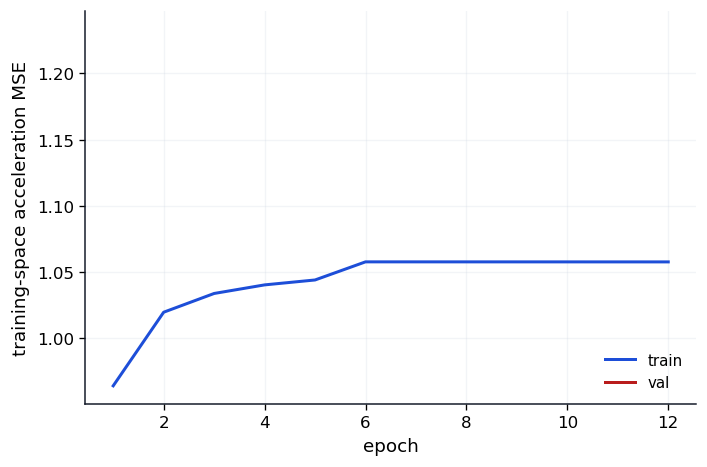

CVs=1: validation rollout during training


,epoch,rollout_r2,rollout_pos_mse,rollout_pearson,used,total
1,2,-0.749479,0.000003,0.774230,20,20
3,4,-0.749709,0.000003,0.775609,20,20
5,6,-0.749440,0.000003,0.775887,20,20
7,8,-0.749599,0.000003,0.774259,20,20
9,10,-0.749646,0.000003,0.773670,20,20
11,12,-0.749378,0.000003,0.772238,20,20


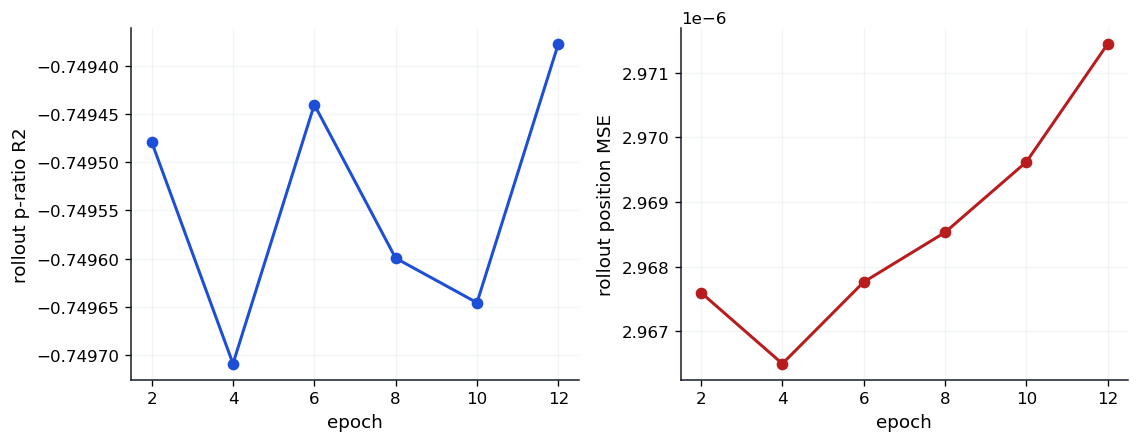

In [4]:
for run_ctx in run_contexts:
    CVs = run_ctx['CVs']
    cfg = run_ctx['cfg']
    run_dir = run_ctx['run_dir']
    paper_caption(f'CVs={CVs}: ' + run_ctx['cfg'].run_name)

    # Load the selected checkpoint.

    run_dir = Path(common_cfg['output_root']) / cfg.run_name
    cfg_dict = json.loads((run_dir / 'config.json').read_text())
    cfg_dict.pop('split_info', None)
    cfg_loaded = ExperimentConfig(**cfg_dict)
    device = resolve_device(cfg_loaded.device)
    model_inputs_cls = resolve_model_inputs(cfg_loaded.model_type)

    train_data, val_data, test_data, split_info = resolve_dataset_splits(
        cfg_loaded.dataset_path,
        train_count=cfg_loaded.train_count,
        val_count=cfg_loaded.val_count,
        dataset_mixture=cfg_loaded.dataset_mixture,
        split_seed=cfg_loaded.split_seed,
        shuffle_within_source=cfg_loaded.shuffle_dataset_within_source,
        mix_holdout_across_sources=cfg_loaded.mix_holdout_across_sources,
    )
    train_source_rows = source_rows_for_split(cfg_loaded, 'train')
    val_source_rows = source_rows_for_split(cfg_loaded, 'val')
    test_source_rows = source_rows_for_split(cfg_loaded, 'test')

    init_graph = build_graph([val_data[0][i].to(device) for i in range(cfg_loaded.history + 1)], node_features=cfg_loaded.node_features).to(device)
    model = create_model(
        model_type=cfg_loaded.model_type,
        init_graph=init_graph,
        pos_dim=cfg_loaded.pos_dim,
        hidden_size=cfg_loaded.hidden_size,
        n_layers=cfg_loaded.n_layers,
        extras=cfg_loaded.model_extras,
    ).to(device)
    checkpoint = torch.load(run_dir / 'final_checkpoint.pt', map_location='cpu', weights_only=False)
    checkpoint_target = checkpoint.get('cfg', {}).get('model_extras', {}).get('prediction_target', 'acceleration')
    loaded_target = cfg_loaded.model_extras.get('prediction_target', 'acceleration')
    print('checkpoint:', run_dir / 'final_checkpoint.pt')
    print('config prediction_target:', loaded_target)
    print('checkpoint prediction_target:', checkpoint_target)
    if checkpoint_target != loaded_target:
        raise ValueError(f'checkpoint prediction_target={checkpoint_target!r} does not match config prediction_target={loaded_target!r}')
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    model.freeze_normalizers = True

    stats = torch.load(run_dir / 'train_stats.pt', map_location='cpu', weights_only=False)
    run_ctx.update({
        'cfg_loaded': cfg_loaded,
        'device': device,
        'model_inputs_cls': model_inputs_cls,
        'train_data': train_data,
        'val_data': val_data,
        'test_data': test_data,
        'split_info': split_info,
        'train_source_rows': train_source_rows,
        'val_source_rows': val_source_rows,
        'test_source_rows': test_source_rows,
        'model': model,
        'stats': stats,
    })
    fig, ax = plt.subplots(1, 1, figsize=(6.0, 4.0))
    ax.plot(stats['epoch'], stats['loss'], color=PAPER_COLORS['blue'], lw=1.8, label='train')
    ax.plot(stats['epoch'], stats['val_loss'], color=PAPER_COLORS['red'], lw=1.8, label='val')
    target_label = 'velocity' if getattr(model, 'prediction_target', 'acceleration') == 'velocity' else 'acceleration'
    loss_label = f'{target_label} MSE' if not getattr(model, 'use_normalization', True) else f'training-space {target_label} MSE'
    style_axes(ax, xlabel='epoch', ylabel=loss_label, legend=True)
    plt.tight_layout()
    plt.show()

    if 'rollout_r2' in stats and np.isfinite(np.asarray(stats['rollout_r2'], dtype=float)).any():
        rollout_df = pd.DataFrame({
            'epoch': stats['epoch'],
            'rollout_r2': stats['rollout_r2'],
            'rollout_pos_mse': np.asarray(stats['rollout_pos_mse'], dtype=float),
            'rollout_pearson': stats['rollout_pearson_r'],
            'used': stats['rollout_used'],
            'total': stats['rollout_total'],
        }).replace([np.inf, -np.inf], np.nan).dropna(subset=['rollout_r2', 'rollout_pos_mse'], how='all')
        paper_caption(f'CVs={CVs}: validation rollout during training')
        display(rollout_df.round(6))
        fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.8))
        axes[0].plot(rollout_df['epoch'], rollout_df['rollout_r2'], marker='o', color=PAPER_COLORS['blue'], lw=1.8)
        style_axes(axes[0], xlabel='epoch', ylabel='rollout p-ratio R2')
        axes[1].plot(rollout_df['epoch'], rollout_df['rollout_pos_mse'], marker='o', color=PAPER_COLORS['red'], lw=1.8)
        style_axes(axes[1], xlabel='epoch', ylabel='rollout position MSE')
        plt.tight_layout()
        plt.show()





CVs=1: linear_cv_simulator_cv1_edge_pyramid


Short validation rollout: all validation sources, 80 steps


,source,steps,used,total,pos_mse,p_ratio_r2,p_ratio_pearson
0,all validation sources,80,95,95,0.00005,-0.57689,0.82831


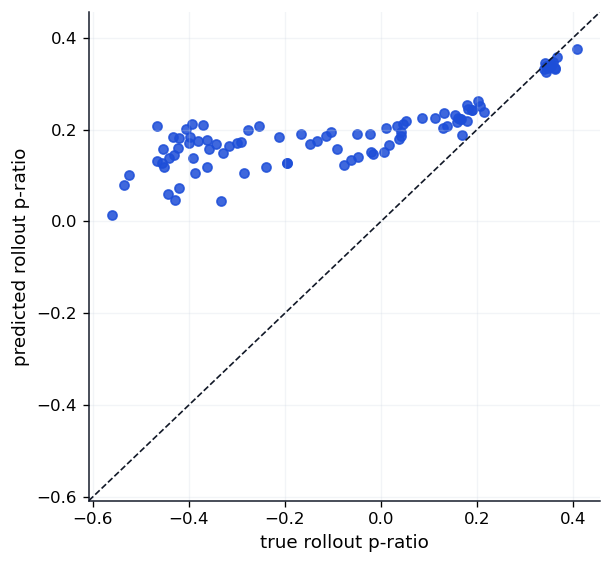

In [5]:
for run_ctx in run_contexts:
    CVs = run_ctx['CVs']
    cfg = run_ctx['cfg']
    run_dir = run_ctx['run_dir']
    paper_caption(f'CVs={CVs}: ' + run_ctx['cfg'].run_name)

    cfg_loaded = run_ctx['cfg_loaded']
    device = run_ctx['device']
    model_inputs_cls = run_ctx['model_inputs_cls']
    train_data = run_ctx['train_data']
    val_data = run_ctx['val_data']
    test_data = run_ctx['test_data']
    split_info = run_ctx['split_info']
    train_source_rows = run_ctx['train_source_rows']
    val_source_rows = run_ctx['val_source_rows']
    test_source_rows = run_ctx['test_source_rows']
    model = run_ctx['model']
    stats = run_ctx.get('stats')

    # Short autoregressive validation rollout.

    short_rollout_steps = 80
    val_rollout_source = None

    rollout_sims = val_data + test_data
    if val_rollout_source is not None:
        rollout_sims = [sim for sim, row in zip(val_data, val_source_rows) if row['source'] == val_rollout_source]

    with torch.no_grad():
        rollout_metrics = evaluate_rollout_pratio_sides(
            model=model,
            sims=rollout_sims,
            history=cfg_loaded.history,
            rollout_steps=short_rollout_steps,
            pos_dim=cfg_loaded.pos_dim,
            device=device,
            model_inputs_cls=model_inputs_cls,
            node_features=cfg_loaded.node_features,
        )

    rollout_mse = float(rollout_metrics['rollout_pos_mse'])
    source_label = 'all validation sources'
    paper_caption(f'Short validation rollout: {source_label}, {short_rollout_steps} steps')
    display(pd.DataFrame([{
        'source': source_label,
        'steps': short_rollout_steps,
        'used': rollout_metrics['used'],
        'total': rollout_metrics['total'],
        'pos_mse': rollout_mse,
        'p_ratio_r2': rollout_metrics['rollout_r2'],
        'p_ratio_pearson': rollout_metrics['rollout_pearson_r'],
    }]).round(5))

    rows = pd.DataFrame(rollout_metrics['rows'])
    if len(rows):
        fig, ax = plt.subplots(1, 1, figsize=(5.2, 4.8))
        x = rows['target_rollout_sides_p_ratio'].to_numpy(dtype=float)
        y = rows['pred_rollout_p_ratio'].to_numpy(dtype=float)
        lo, hi = float(np.nanmin(np.r_[x, y])), float(np.nanmax(np.r_[x, y]))
        pad = max(0.05 * (hi - lo), 1e-6)
        ax.scatter(x, y, s=30, color=PAPER_COLORS['blue'], alpha=0.85)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color=PAPER_COLORS['ink'], ls='--', lw=1.0)
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        style_axes(ax, xlabel='true rollout p-ratio', ylabel='predicted rollout p-ratio')
        plt.tight_layout()
        plt.show()



In [6]:
for run_ctx in run_contexts:
    CVs = run_ctx['CVs']
    cfg = run_ctx['cfg']
    run_dir = run_ctx['run_dir']
    paper_caption(f'CVs={CVs}: ' + run_ctx['cfg'].run_name)

    cfg_loaded = run_ctx['cfg_loaded']
    device = run_ctx['device']
    model_inputs_cls = run_ctx['model_inputs_cls']
    train_data = run_ctx['train_data']
    val_data = run_ctx['val_data']
    test_data = run_ctx['test_data']
    split_info = run_ctx['split_info']
    train_source_rows = run_ctx['train_source_rows']
    val_source_rows = run_ctx['val_source_rows']
    test_source_rows = run_ctx['test_source_rows']
    model = run_ctx['model']
    stats = run_ctx.get('stats')

    # Extract frame-level CVs and trajectory summaries.

    def extract_cv_frames(sims, split_name, source_rows):
        rows = []
        with torch.no_grad():
            for sim_idx, sim in enumerate(sims):
                meta = source_rows[sim_idx]
                final_p_ratio = float(calc_p_ratio_box(sim, -1))
                for t in range(cfg_loaded.history, len(sim) - 1):
                    graph = build_graph(frame_window(sim, t, cfg_loaded, device), node_features=cfg_loaded.node_features).to(device)
                    cv = model.extract_cv(graph, is_training=False).squeeze(0).detach().cpu().numpy()
                    pos = sim[t].x[:, : cfg_loaded.pos_dim].detach().cpu().numpy()
                    next_pos = sim[t + 1].x[:, : cfg_loaded.pos_dim].detach().cpu().numpy()
                    row = {
                        'split': split_name,
                        'source': meta['source'],
                        'sim_idx': sim_idx,
                        'source_sim_idx': meta['source_sim_idx'],
                        't': int(t),
                        'final_p_ratio': final_p_ratio,
                        'width_y': float(np.mean(np.abs(pos[:, 1]))),
                        'delta_width_y_next': float(np.mean(np.abs(next_pos[:, 1])) - np.mean(np.abs(pos[:, 1]))),
                    }
                    for i, value in enumerate(np.asarray(cv, dtype=float).reshape(-1), start=1):
                        row[f'cv_{i}'] = float(value)
                    rows.append(row)
        return pd.DataFrame(rows)


    def summarize_cv(df, cols):
        group_cols = ['split', 'source', 'sim_idx', 'source_sim_idx']
        out = df.groupby(group_cols, as_index=False)[cols].mean()
        final = df.groupby(group_cols, as_index=False)['final_p_ratio'].first()
        count = df.groupby(group_cols, as_index=False).size().rename(columns={'size': 'num_frames'})
        return out.merge(final, on=group_cols).merge(count, on=group_cols)


    def add_cv_linear_combo(df_val_frames, df_test_frames, cv_cols, max_terms=5):
        val_summary = summarize_cv(df_val_frames, cv_cols)
        y = val_summary['final_p_ratio'].to_numpy(dtype=float)
        best = None
        max_terms = min(int(max_terms), len(cv_cols))
        for subset_size in range(1, max_terms + 1):
            for subset in itertools.combinations(cv_cols, subset_size):
                x = val_summary[list(subset)].to_numpy(dtype=float)
                x_centered = x - x.mean(axis=0, keepdims=True)
                y_centered = y - y.mean()
                cov_xx = (x_centered.T @ x_centered) / max(len(x_centered) - 1, 1)
                cov_xy = (x_centered.T @ y_centered) / max(len(x_centered) - 1, 1)
                weights = np.linalg.pinv(cov_xx) @ cov_xy
                norm = float(np.linalg.norm(weights))
                if norm > 1e-12:
                    weights = weights / norm
                combo_values = x @ weights
                corr = float(np.corrcoef(combo_values, y)[0, 1]) if len(x) > 1 and not np.allclose(np.std(combo_values), 0.0) else 0.0
                if np.isfinite(corr) and corr < 0:
                    weights = -weights
                    combo_values = -combo_values
                fit = np.polyfit(combo_values, y, deg=1) if len(combo_values) > 1 and not np.allclose(np.std(combo_values), 0.0) else [0.0, float(np.mean(y))]
                y_hat = fit[0] * combo_values + fit[1]
                ss_tot = float(np.sum((y - np.mean(y)) ** 2))
                ss_res = float(np.sum((y - y_hat) ** 2))
                r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float('nan')
                rmse = float(np.sqrt(np.mean((y - y_hat) ** 2)))
                key = (np.nan_to_num(r2, nan=-np.inf), -rmse)
                if best is None or key > best['key']:
                    best = {'key': key, 'terms': list(subset), 'weights': weights}

        selected_terms = best['terms']
        weights = best['weights']
        for df in (df_val_frames, df_test_frames):
            df['cv_combo'] = df[selected_terms].to_numpy(dtype=float) @ weights

        combo = pd.DataFrame({
            'term': selected_terms,
            'weight': weights.tolist(),
        })
        return combo


    df_val_frames = extract_cv_frames(val_data, 'val', val_source_rows)
    df_test_frames = extract_cv_frames(test_data, 'test', test_source_rows)
    base_cv_cols = [c for c in df_val_frames.columns if c.startswith('cv_')]
    cv_combo_weights = add_cv_linear_combo(df_val_frames, df_test_frames, base_cv_cols)
    df_all_frames = pd.concat([df_val_frames, df_test_frames], ignore_index=True)
    cv_cols = base_cv_cols + ['cv_combo']
    selected_cv_col = 'cv_combo'

    df_val = summarize_cv(df_val_frames, cv_cols)
    df_test = summarize_cv(df_test_frames, cv_cols)

    run_ctx.update({
        'df_val_frames': df_val_frames,
        'df_test_frames': df_test_frames,
        'df_all_frames': df_all_frames,
        'df_val': df_val,
        'df_test': df_test,
        'base_cv_cols': base_cv_cols,
        'cv_combo_weights': cv_combo_weights,
        'cv_cols': cv_cols,
        'selected_cv_col': selected_cv_col,
    })

    paper_caption('Raw CV correlation combo chosen on validation trajectory means')
    display(cv_combo_weights.round(5))
    display(df_test.assign(dataset='test').head().round(4))


CVs=1: linear_cv_simulator_cv1_edge_pyramid


Raw CV correlation combo chosen on validation trajectory means


,term,weight
0,cv_1,1.0


,split,source,sim_idx,source_sim_idx,cv_1,cv_combo,final_p_ratio,num_frames,dataset
0,test,De Pablo,0,96,0.0110,0.0110,0.1728,161,test
1,test,De Pablo,1,38,0.0078,0.0078,0.3526,149,test
2,test,De Pablo,2,81,-0.0092,-0.0092,-0.3448,161,test
3,test,De Pablo,3,59,0.0049,0.0049,-0.0175,170,test
4,test,De Pablo,4,93,-0.0095,-0.0095,-0.3823,138,test


Test-set Raw CV correlation combo versus final p-ratio, side by side


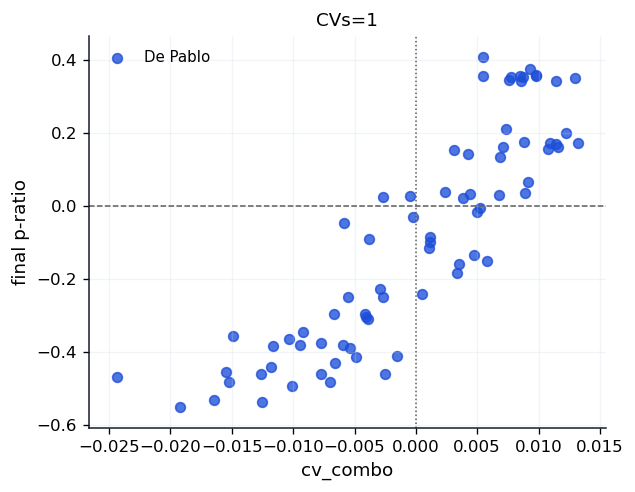

Test-set Raw CV correlation combo versus next-step y-width change, side by side


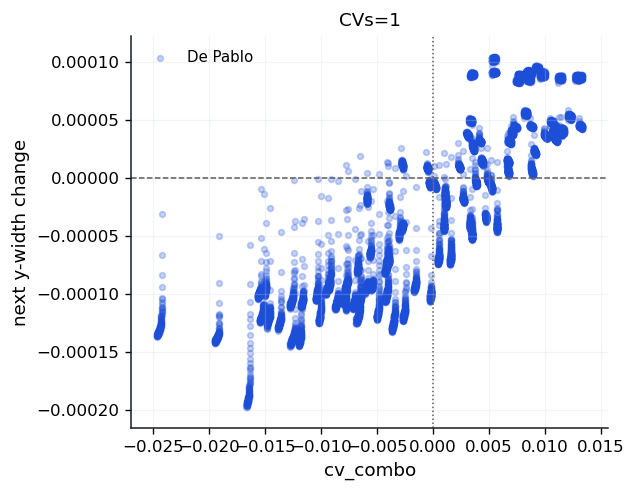

,CVs,split,cv,corr_cv_final_p_ratio,corr_cv_next_y_width_change
0,1,test,cv_combo,0.8798,0.8804


In [7]:
# Main side-by-side plots: Raw CV correlation combo versus p-ratio and next y-width change.

required_keys = {'df_val', 'df_test', 'df_val_frames', 'df_test_frames', 'df_all_frames', 'cv_cols', 'selected_cv_col'}
missing = [ctx['CVs'] for ctx in run_contexts if not required_keys.issubset(ctx)]
if missing:
    raise RuntimeError(f'Run cell 6 before this plotting cell. Missing CV tables for CV counts: {missing}')

paper_caption('Test-set Raw CV correlation combo versus final p-ratio, side by side')
fig, axes = plt.subplots(1, len(run_contexts), figsize=(5.4 * len(run_contexts), 4.2), squeeze=False)
for ax, ctx in zip(axes[0], run_contexts):
    selected_cv_col = ctx['selected_cv_col']
    x_values = []
    y_values = []
    for source, sub in ctx['df_test'].groupby('source'):
        x_values.extend(sub[selected_cv_col].to_numpy(dtype=float))
        y_values.extend(sub['final_p_ratio'].to_numpy(dtype=float))
        ax.scatter(
            sub[selected_cv_col],
            sub['final_p_ratio'],
            s=34,
            alpha=0.78,
            color=SOURCE_COLORS.get(source, PAPER_COLORS['slate']),
            label=source,
        )
    ax.axhline(0.0, color='0.35', lw=0.9, ls='--')
    ax.axvline(0.0, color='0.35', lw=0.9, ls=':')
    set_tight_data_limits(ax, x_values, y_values)
    ax.set_title(f"CVs={ctx['CVs']}")
    style_axes(ax, xlabel=selected_cv_col, ylabel='final p-ratio' if ax is axes[0, 0] else None, legend=True)
plt.tight_layout()
plt.show()

paper_caption('Test-set Raw CV correlation combo versus next-step y-width change, side by side')
fig, axes = plt.subplots(1, len(run_contexts), figsize=(5.4 * len(run_contexts), 4.2), squeeze=False)
for ax, ctx in zip(axes[0], run_contexts):
    selected_cv_col = ctx['selected_cv_col']
    x_values = []
    y_values = []
    for source, sub in ctx['df_all_frames'].groupby('source'):
        x_values.extend(sub[selected_cv_col].to_numpy(dtype=float))
        y_values.extend(sub['delta_width_y_next'].to_numpy(dtype=float))
        ax.scatter(sub[selected_cv_col], sub['delta_width_y_next'], s=12, alpha=0.25, color=SOURCE_COLORS.get(source, PAPER_COLORS['slate']), label=source)
    ax.axhline(0.0, color='0.35', lw=0.9, ls='--')
    ax.axvline(0.0, color='0.35', lw=0.9, ls=':')
    set_tight_data_limits(ax, x_values, y_values)
    ax.set_title(f"CVs={ctx['CVs']}")
    style_axes(ax, xlabel=selected_cv_col, ylabel='next y-width change' if ax is axes[0, 0] else None, legend=True)
plt.tight_layout()
plt.show()

summary = []
for ctx in run_contexts:
    split = 'test'
    df = ctx['df_test_frames']
    summarized = summarize_cv(df, ctx['cv_cols'])
    summary.append({
        'CVs': ctx['CVs'],
        'split': split,
        'cv': ctx['selected_cv_col'],
        'corr_cv_final_p_ratio': float(pd.Series(summarized[ctx['selected_cv_col']]).corr(pd.Series(summarized['final_p_ratio']))),
        'corr_cv_next_y_width_change': float(pd.Series(df[ctx['selected_cv_col']]).corr(pd.Series(df['delta_width_y_next']))),
    })
display(pd.DataFrame(summary).round(4))


Accumulated middle-window position change, side by side


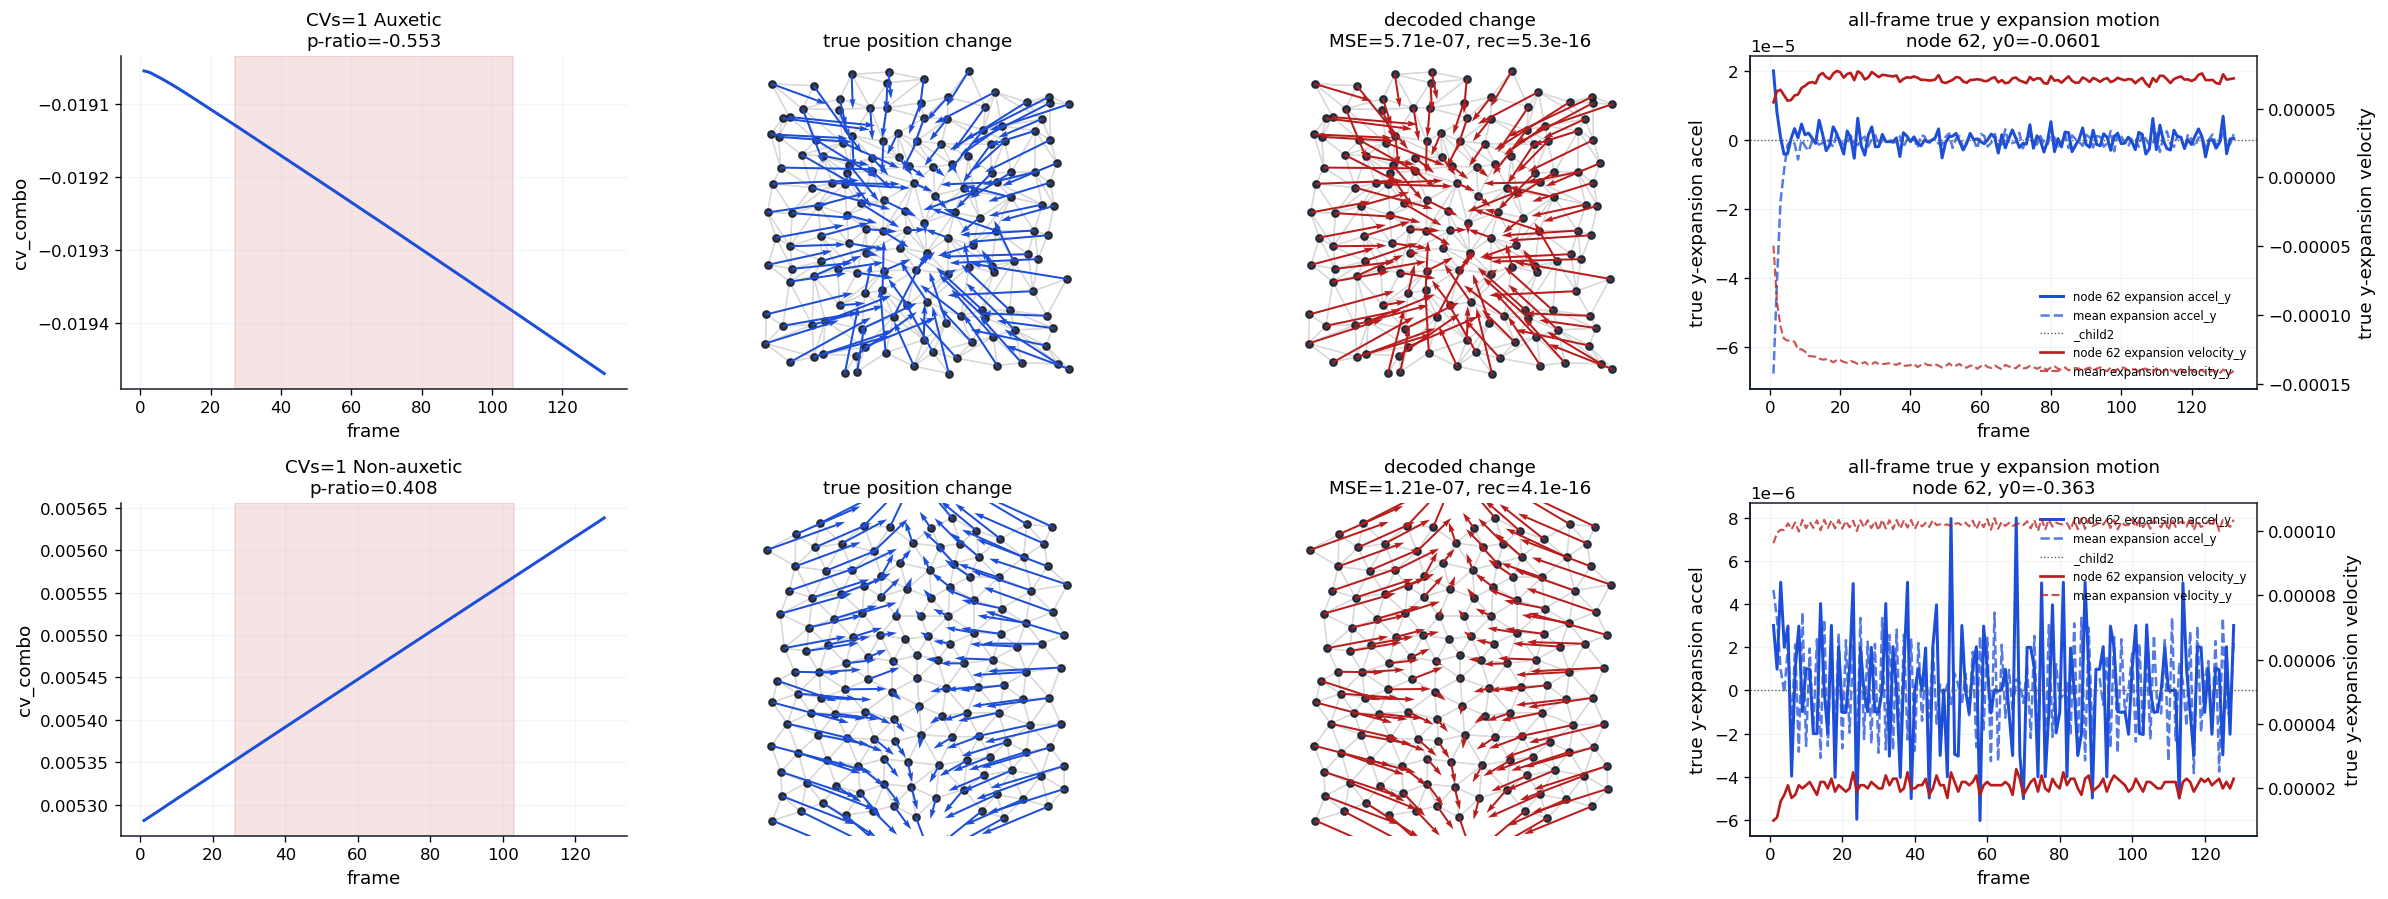

Frame-level CV combo versus true mean y-expansion acceleration


,CVs,selection,pearson_r,n_frames
0,1,auxetic,-0.26188,132
1,1,non_auxetic,-0.05276,128


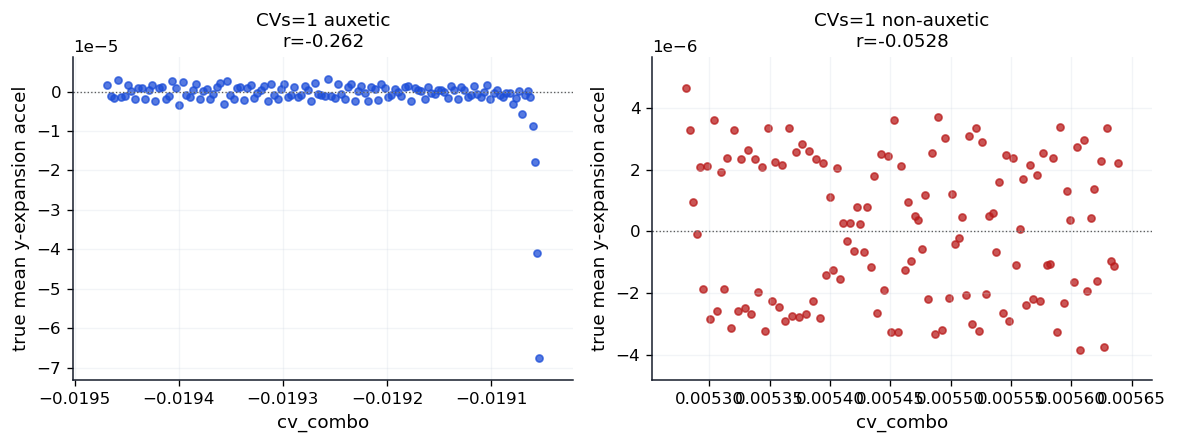

One-step middle-window decoder contribution summary using raw CV values


,CVs,selection,term,raw_cv_value,mean_ax,mean_ay,mean_abs_acceleration,reconstruction_mse
0,1,auxetic,baseline,,-0.0,0.0,0.0,0.0
1,1,auxetic,cv_1,-0.019254,0.0,0.0,0.0,0.0
2,1,auxetic,full,,0.0,0.0,0.0,0.0
3,1,non_auxetic,baseline,,-0.0,0.0,0.0,0.0
4,1,non_auxetic,cv_1,0.005459,-0.0,0.0,0.0,0.0
5,1,non_auxetic,full,,-0.0,0.0,0.0,0.0


In [8]:
# Side-by-side decoder diagnostics for CV-count comparison.

required_keys = {'df_val', 'df_test', 'df_val_frames', 'df_test_frames', 'base_cv_cols', 'cv_combo_weights', 'model'}
missing = [ctx['CVs'] for ctx in run_contexts if not required_keys.issubset(ctx)]
if missing:
    raise RuntimeError(f'Run cells 4-7 before this diagnostic cell. Missing context for CV counts: {missing}')


def bind_context(ctx):
    return {
        'CVs': ctx['CVs'],
        'cfg_loaded': ctx['cfg_loaded'],
        'device': ctx['device'],
        'model_inputs_cls': ctx['model_inputs_cls'],
        'train_data': ctx['train_data'],
        'val_data': ctx['val_data'],
        'test_data': ctx['test_data'],
        'train_source_rows': ctx['train_source_rows'],
        'val_source_rows': ctx['val_source_rows'],
        'test_source_rows': ctx['test_source_rows'],
        'model': ctx['model'],
        'df_val': ctx['df_val'],
        'df_test': ctx['df_test'],
        'base_cv_cols': ctx['base_cv_cols'],
        'cv_combo_weights': ctx['cv_combo_weights'],
        'selected_cv_col': ctx['selected_cv_col'],
    }


def inverse_output_delta(model_local, pred_norm):
    if not getattr(model_local, 'use_normalization', True):
        return pred_norm
    return pred_norm * model_local.output_normalizer._std_with_epsilon()


def output_offset_array(model_local, cfg_local, num_nodes):
    if not getattr(model_local, 'use_normalization', True):
        return np.zeros((num_nodes, cfg_local.pos_dim), dtype=float)
    offset = model_local.output_normalizer._mean().detach().cpu().numpy().reshape(1, -1)
    return np.repeat(offset[:, : cfg_local.pos_dim], num_nodes, axis=0)


def direct_decoder_motion(ctx, graph, cv_mask=None, include_output_offset=True):
    model_local = ctx['model']
    device_local = ctx['device']
    with torch.no_grad():
        cv, pred = model_local.predict_motion_from_cv(
            graph.to(device_local),
            cv_mask=cv_mask,
            include_output_offset=include_output_offset,
            is_training=False,
        )
    return cv.detach().cpu().numpy(), pred.detach().cpu().numpy()


def all_trajectory_rows(ctx):
    rows = []
    for split_name, sims, source_rows in [
        ('train', ctx['train_data'], ctx['train_source_rows']),
        ('val', ctx['val_data'], ctx['val_source_rows']),
        ('test', ctx['test_data'], ctx['test_source_rows']),
    ]:
        for sim_idx, sim in enumerate(sims):
            meta = source_rows[sim_idx]
            rows.append({
                'split': split_name,
                'source': meta['source'],
                'sim_idx': int(sim_idx),
                'source_sim_idx': int(meta['source_sim_idx']),
                'final_p_ratio': float(calc_p_ratio_box(sim, -1)),
            })
    return pd.DataFrame(rows)


def choose_extreme_trajectory(ctx, selection):
    ascending = selection == 'auxetic'
    return all_trajectory_rows(ctx).sort_values('final_p_ratio', ascending=ascending).iloc[0]


def sim_for_traj(ctx, traj):
    return {'train': ctx['train_data'], 'val': ctx['val_data'], 'test': ctx['test_data']}[traj['split']][int(traj['sim_idx'])]


def cv_combo_value(ctx, cv):
    cv_row = {f'cv_{i}': float(value) for i, value in enumerate(np.asarray(cv).reshape(-1), start=1)}
    combo_lookup = ctx['cv_combo_weights'].set_index('term')
    value = 0.0
    for col in ctx['base_cv_cols']:
        value += float(combo_lookup.loc[col, 'weight']) * cv_row[col]
    return value


def cv_frame_table(ctx, sim):
    rows = []
    cfg_local = ctx['cfg_loaded']
    for t in range(cfg_local.history, len(sim) - 1):
        graph = build_graph(frame_window(sim, t, cfg_local, ctx['device']), node_features=cfg_local.node_features).to(ctx['device'])
        cv, _ = direct_decoder_motion(ctx, graph)
        row = {'t': int(t), 'cv_combo': cv_combo_value(ctx, cv)}
        for i, value in enumerate(np.asarray(cv).reshape(-1), start=1):
            row[f'cv_{i}'] = float(value)
        rows.append(row)
    return pd.DataFrame(rows)


def decoded_position_case(ctx, selection):
    cfg_local = ctx['cfg_loaded']
    base_cv_cols = ctx['base_cv_cols']
    traj = choose_extreme_trajectory(ctx, selection)
    sim = sim_for_traj(ctx, traj)
    frames = cv_frame_table(ctx, sim)
    start_idx = int(np.floor(0.20 * len(frames)))
    end_idx = int(np.ceil(0.80 * len(frames))) - 1
    end_idx = max(start_idx + 1, min(end_idx, len(frames) - 2))
    start_t = int(frames.iloc[start_idx]['t'])
    end_t = int(frames.iloc[end_idx]['t'])

    start_graph = build_graph(frame_window(sim, start_t, cfg_local, ctx['device']), node_features=cfg_local.node_features).to(ctx['device'])
    start_pos = start_graph.x[:, : cfg_local.pos_dim].detach().cpu().numpy()
    edge_pairs = visible_edges(start_graph, start_pos)
    initial_vel = start_pos - sim[start_t - 1].x[:, : cfg_local.pos_dim].detach().cpu().numpy()
    decoded_dp = np.zeros_like(start_pos)
    decoded_vel = initial_vel.copy()
    baseline_dp = np.zeros_like(start_pos)
    baseline_vel = initial_vel.copy()
    component_dp = {col: np.zeros_like(start_pos) for col in base_cv_cols}
    component_vel = {col: np.zeros_like(start_pos) for col in base_cv_cols}

    for frame_idx in range(start_idx, end_idx):
        t = int(frames.iloc[frame_idx]['t'])
        graph = build_graph(frame_window(sim, t, cfg_local, ctx['device']), node_features=cfg_local.node_features).to(ctx['device'])
        _, decoded_motion = direct_decoder_motion(ctx, graph)
        baseline_motion = output_offset_array(ctx['model'], cfg_local, start_pos.shape[0])
        for cv_idx, col in enumerate(base_cv_cols):
            mask = np.zeros(len(base_cv_cols), dtype=float)
            mask[cv_idx] = 1.0
            _, component_motion = direct_decoder_motion(ctx, graph, cv_mask=mask, include_output_offset=False)
            component_motion = component_motion[:, : cfg_local.pos_dim]
            if getattr(ctx['model'], 'prediction_target', 'acceleration') == 'velocity':
                component_vel[col] = component_motion
            else:
                component_vel[col] += component_motion
            component_dp[col] += component_vel[col]
        if getattr(ctx['model'], 'prediction_target', 'acceleration') == 'velocity':
            baseline_vel = baseline_motion
            decoded_vel = decoded_motion[:, : cfg_local.pos_dim]
        else:
            baseline_vel += baseline_motion
            decoded_vel += decoded_motion[:, : cfg_local.pos_dim]
        baseline_dp += baseline_vel
        decoded_dp += decoded_vel

    true_dp = sim[end_t].x[:, : cfg_local.pos_dim].detach().cpu().numpy() - start_pos
    probe_idx = (start_idx + end_idx) // 2
    probe_t = int(frames.iloc[probe_idx]['t'])
    probe_graph = build_graph(frame_window(sim, probe_t, cfg_local, ctx['device']), node_features=cfg_local.node_features).to(ctx['device'])
    probe_pos = probe_graph.x[:, : cfg_local.pos_dim].detach().cpu().numpy()
    _, probe_full_motion = direct_decoder_motion(ctx, probe_graph)
    probe_baseline_motion = output_offset_array(ctx['model'], cfg_local, probe_pos.shape[0])
    probe_component_motion = {}
    probe_cv = {}
    for cv_idx, col in enumerate(base_cv_cols):
        mask = np.zeros(len(base_cv_cols), dtype=float)
        mask[cv_idx] = 1.0
        cv, component_motion = direct_decoder_motion(ctx, probe_graph, cv_mask=mask, include_output_offset=False)
        probe_component_motion[col] = component_motion[:, : cfg_local.pos_dim]
        probe_cv[col] = float(np.asarray(cv, dtype=float).reshape(-1)[cv_idx])

    reconstructed_dp = baseline_dp + sum(component_dp.values())
    return {
        'selection': selection,
        'traj': traj,
        'frames': frames,
        'start_t': start_t,
        'end_t': end_t,
        'pos': start_pos,
        'edges': edge_pairs,
        'true_dp': true_dp,
        'decoded_dp': decoded_dp,
        'baseline_dp': baseline_dp,
        'component_dp': component_dp,
        'reconstructed_dp': reconstructed_dp,
        'reconstruction_mse': float(np.mean((reconstructed_dp - decoded_dp) ** 2)),
        'mse': float(np.mean((decoded_dp - true_dp) ** 2)),
        'cosine': float(np.sum(decoded_dp * true_dp) / (np.linalg.norm(decoded_dp) * np.linalg.norm(true_dp) + 1e-12)),
        'probe_t': probe_t,
        'probe_pos': probe_pos,
        'probe_edges': visible_edges(probe_graph, probe_pos),
        'probe_cv': probe_cv,
        'probe_full_motion': probe_full_motion[:, : cfg_local.pos_dim],
        'probe_baseline_motion': probe_baseline_motion,
        'probe_component_motion': probe_component_motion,
        'accel_probe_node_idx': int(np.argmin(np.linalg.norm(probe_pos[:, :2], axis=1))),
    }


comparison_contexts = []
for source_ctx in run_contexts:
    ctx = bind_context(source_ctx)
    ctx['cases'] = [decoded_position_case(ctx, 'auxetic'), decoded_position_case(ctx, 'non_auxetic')]
    source_ctx['comparison_cases'] = ctx['cases']
    comparison_contexts.append(ctx)

# 1. Accumulated position change over the same middle 60% window.
all_vectors = []
all_positions = []
for ctx in comparison_contexts:
    for case in ctx['cases']:
        all_vectors.extend([case['true_dp'][:, :2], case['decoded_dp'][:, :2]])
        all_positions.extend([case['pos'][:, :2], case['pos'][:, :2]])
position_scale = arrow_scale(np.vstack(all_positions), np.vstack(all_vectors), target_fraction=0.32)

paper_caption('Accumulated middle-window position change, side by side')
fig, axes = plt.subplots(2, len(comparison_contexts) * 4, figsize=(5.0 * len(comparison_contexts) * 4, 7.6), squeeze=False)
for ctx_idx, ctx in enumerate(comparison_contexts):
    for row_idx, case in enumerate(ctx['cases']):
        title = 'Auxetic' if case['selection'] == 'auxetic' else 'Non-auxetic'
        base_col = ctx_idx * 4
        ax = axes[row_idx, base_col]
        ax.plot(case['frames']['t'], case['frames'][ctx['selected_cv_col']], color=PAPER_COLORS['blue'], lw=1.8)
        ax.axvspan(case['start_t'], case['end_t'], color=PAPER_COLORS['red'], alpha=0.12)
        ax.set_title(f"CVs={ctx['CVs']} {title}\np-ratio={float(case['traj']['final_p_ratio']):.3f}")
        style_axes(ax, xlabel='frame', ylabel=ctx['selected_cv_col'])
        draw_field(axes[row_idx, base_col + 1], case['pos'], case['true_dp'], case['edges'], PAPER_COLORS['blue'], 'true position change', vector_scale=position_scale)
        draw_field(
            axes[row_idx, base_col + 2],
            case['pos'],
            case['decoded_dp'],
            case['edges'],
            PAPER_COLORS['red'],
            f"decoded change\nMSE={case['mse']:.3g}, rec={case['reconstruction_mse']:.2g}",
            vector_scale=position_scale,
        )
        node_idx = int(case['accel_probe_node_idx'])
        node_times = []
        node_accel_y = []
        mean_accel_y = []
        node_vel_y = []
        mean_vel_y = []
        cfg_local = ctx['cfg_loaded']
        sim = sim_for_traj(ctx, case['traj'])
        for _, frame_row in case['frames'].iterrows():
            t = int(frame_row['t'])
            prev_pos_all = sim[t - 1].x[:, : cfg_local.pos_dim].detach().cpu().numpy()
            cur_pos_all = sim[t].x[:, : cfg_local.pos_dim].detach().cpu().numpy()
            next_pos_all = sim[t + 1].x[:, : cfg_local.pos_dim].detach().cpu().numpy()
            prev_vel_all = cur_pos_all - prev_pos_all
            next_vel_all = next_pos_all - cur_pos_all
            true_accel_all = next_vel_all - prev_vel_all
            y_sign = np.sign(cur_pos_all[:, 1])
            node_times.append(t)
            node_accel_y.append(float(y_sign[node_idx] * true_accel_all[node_idx, 1]))
            mean_accel_y.append(float(np.mean(y_sign * true_accel_all[:, 1])))
            node_vel_y.append(float(y_sign[node_idx] * next_vel_all[node_idx, 1]))
            mean_vel_y.append(float(np.mean(y_sign * next_vel_all[:, 1])))
        ax_acc = axes[row_idx, base_col + 3]
        ax_acc.plot(node_times, node_accel_y, color=PAPER_COLORS['blue'], lw=1.8, label=f'node {node_idx} expansion accel_y')
        ax_acc.plot(node_times, mean_accel_y, color=PAPER_COLORS['blue'], lw=1.5, ls='--', alpha=0.75, label='mean expansion accel_y')
        ax_acc.axhline(0.0, color='0.35', lw=0.8, ls=':')
        ax_vel = ax_acc.twinx()
        ax_vel.plot(node_times, node_vel_y, color=PAPER_COLORS['red'], lw=1.6, label=f'node {node_idx} expansion velocity_y')
        ax_vel.plot(node_times, mean_vel_y, color=PAPER_COLORS['red'], lw=1.3, ls='--', alpha=0.75, label='mean expansion velocity_y')
        ax_acc.set_title(f"all-frame true y expansion motion\nnode {node_idx}, y0={case['probe_pos'][node_idx, 1]:.3g}")
        style_axes(ax_acc, xlabel='frame', ylabel='true y-expansion accel')
        ax_vel.set_ylabel('true y-expansion velocity')
        lines = ax_acc.get_lines() + ax_vel.get_lines()
        labels = [line.get_label() for line in lines]
        ax_acc.legend(lines, labels, fontsize=7, loc='best', frameon=False)
plt.tight_layout()
plt.show()

# 2. Frame-level check: does CV combo track true mean y-expansion acceleration?
combo_accel_rows = []
for ctx in comparison_contexts:
    cfg_local = ctx['cfg_loaded']
    for case in ctx['cases']:
        selection = 'auxetic' if case['selection'] == 'auxetic' else 'non_auxetic'
        sim = sim_for_traj(ctx, case['traj'])
        combo_lookup = ctx['cv_combo_weights'].set_index('term')
        for _, frame_row in case['frames'].iterrows():
            t = int(frame_row['t'])
            prev_pos_all = sim[t - 1].x[:, : cfg_local.pos_dim].detach().cpu().numpy()
            cur_pos_all = sim[t].x[:, : cfg_local.pos_dim].detach().cpu().numpy()
            next_pos_all = sim[t + 1].x[:, : cfg_local.pos_dim].detach().cpu().numpy()
            prev_vel_all = cur_pos_all - prev_pos_all
            next_vel_all = next_pos_all - cur_pos_all
            true_accel_all = next_vel_all - prev_vel_all
            y_sign = np.sign(cur_pos_all[:, 1])
            mean_expansion_accel_y = float(np.mean(y_sign * true_accel_all[:, 1]))
            cv_combo = 0.0
            for col in ctx['base_cv_cols']:
                cv_combo += float(combo_lookup.loc[col, 'weight']) * float(frame_row[col])
            combo_accel_rows.append({
                'CVs': int(ctx['CVs']),
                'selection': selection,
                't': t,
                'cv_combo': float(cv_combo),
                'mean_y_expansion_accel': mean_expansion_accel_y,
            })
combo_accel_df = pd.DataFrame(combo_accel_rows)
combo_corr_rows = []
for (cv_count, selection), sub in combo_accel_df.groupby(['CVs', 'selection']):
    if len(sub) >= 3 and not np.allclose(sub['cv_combo'].std(), 0.0) and not np.allclose(sub['mean_y_expansion_accel'].std(), 0.0):
        r = float(np.corrcoef(sub['cv_combo'], sub['mean_y_expansion_accel'])[0, 1])
    else:
        r = float('nan')
    combo_corr_rows.append({'CVs': int(cv_count), 'selection': selection, 'pearson_r': r, 'n_frames': int(len(sub))})
combo_corr_df = pd.DataFrame(combo_corr_rows)

paper_caption('Frame-level CV combo versus true mean y-expansion acceleration')
display(combo_corr_df.round(5))
fig, axes = plt.subplots(len(comparison_contexts), 2, figsize=(9.8, 3.8 * len(comparison_contexts)), squeeze=False)
for row_idx, ctx in enumerate(comparison_contexts):
    for col_idx, selection in enumerate(['auxetic', 'non_auxetic']):
        ax = axes[row_idx, col_idx]
        sub = combo_accel_df[(combo_accel_df['CVs'] == int(ctx['CVs'])) & (combo_accel_df['selection'] == selection)]
        ax.scatter(sub['cv_combo'], sub['mean_y_expansion_accel'], s=18, alpha=0.75, color=PAPER_COLORS['blue'] if selection == 'auxetic' else PAPER_COLORS['red'])
        corr = combo_corr_df[(combo_corr_df['CVs'] == int(ctx['CVs'])) & (combo_corr_df['selection'] == selection)]['pearson_r'].iloc[0]
        ax.axhline(0.0, color='0.35', lw=0.8, ls=':')
        ax.axvline(0.0, color='0.35', lw=0.8, ls=':')
        set_tight_data_limits(ax, sub['cv_combo'].to_numpy(), sub['mean_y_expansion_accel'].to_numpy(), pad_fraction=0.08)
        ax.set_title(f"CVs={ctx['CVs']} {selection.replace('_', '-')}\nr={corr:.3g}")
        style_axes(ax, xlabel='cv_combo', ylabel='true mean y-expansion accel')
plt.tight_layout()
plt.show()

# 3. One-step contribution at the middle of the window, before integration.
one_step_rows = []
for ctx in comparison_contexts:
    terms = ['baseline'] + ctx['base_cv_cols'] + ['full']
    for case in ctx['cases']:
        selection = 'auxetic' if case['selection'] == 'auxetic' else 'non_auxetic'
        reconstructed = case['probe_baseline_motion'] + sum(case['probe_component_motion'].values())
        for term in terms:
            if term == 'baseline':
                vectors = case['probe_baseline_motion']
                cv_value = ''
            elif term == 'full':
                vectors = case['probe_full_motion']
                cv_value = ''
            else:
                vectors = case['probe_component_motion'][term]
                cv_value = case['probe_cv'][term]
            one_step_rows.append({
                'CVs': ctx['CVs'],
                'selection': selection,
                'term': term,
                'raw_cv_value': cv_value,
                'mean_ax': float(np.mean(vectors[:, 0])),
                'mean_ay': float(np.mean(vectors[:, 1])),
                'mean_abs_acceleration': float(np.mean(np.linalg.norm(vectors[:, :2], axis=1))),
                'reconstruction_mse': float(np.mean((reconstructed - case['probe_full_motion']) ** 2)),
            })
one_step_df = pd.DataFrame(one_step_rows)
paper_caption('One-step middle-window decoder contribution summary using raw CV values')
display(one_step_df.round(5))



Accumulated middle-window position change encoded by the CV branch only


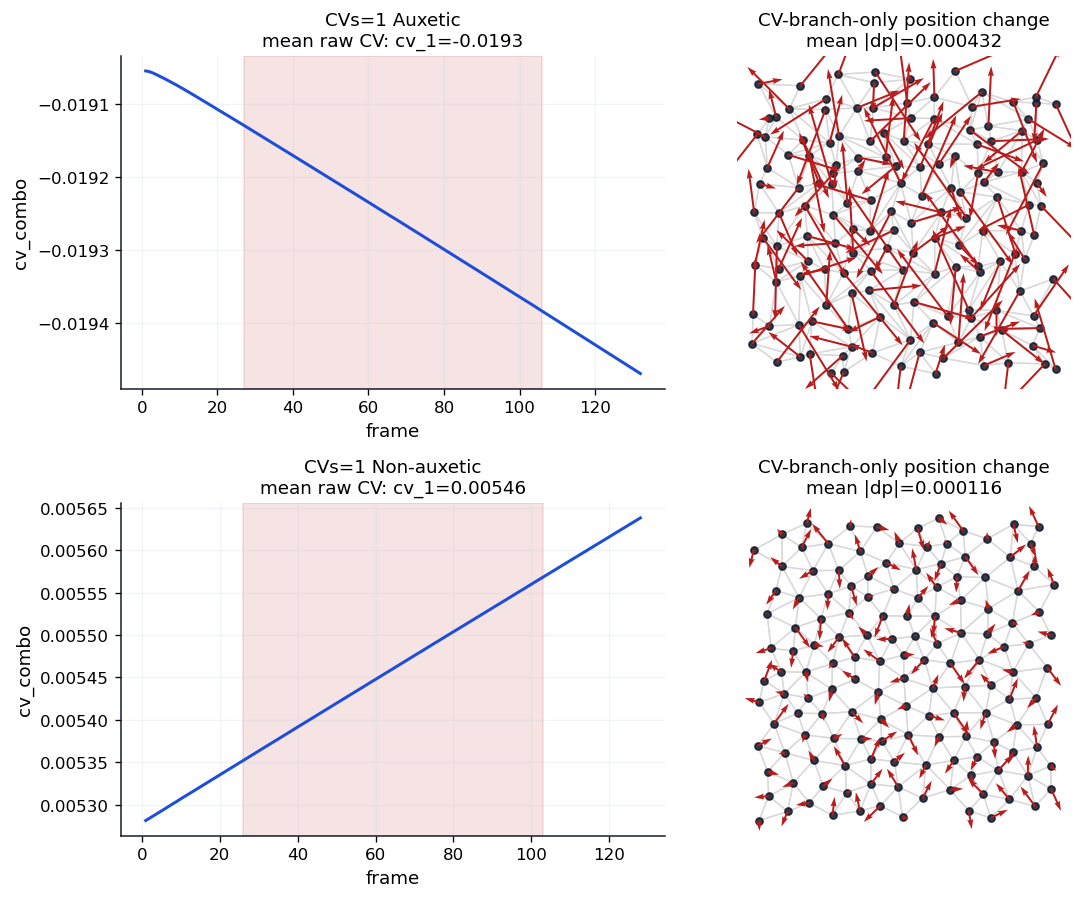

In [9]:
# Middle-window position change encoded by the CV branch only.

if 'comparison_contexts' not in globals():
    raise RuntimeError('Run the side-by-side decoder diagnostic cell first; it creates comparison_contexts.')


def cv_branch_motion(ctx, graph, cv_mask=None):
    """Raw acceleration/velocity contribution from the CV branch only."""
    model_local = ctx['model']
    device_local = ctx['device']
    with torch.no_grad():
        cv, pred = model_local.predict_motion_from_cv(
            graph.to(device_local),
            cv_mask=cv_mask,
            include_output_offset=False,
            is_training=False,
            zero_local_skip=True,
            subtract_zero_cv=True,
        )
    return cv.detach().cpu().numpy(), pred.detach().cpu().numpy()


def cv_branch_position_case(ctx, case):
    cfg_local = ctx['cfg_loaded']
    sim = sim_for_traj(ctx, case['traj'])
    frames = case['frames']
    start_idx = int(frames.index[frames['t'] == case['start_t']][0])
    end_idx = int(frames.index[frames['t'] == case['end_t']][0])
    branch_dp = np.zeros_like(case['pos'])
    branch_vel = np.zeros_like(case['pos'])
    mean_cv_rows = []
    for frame_idx in range(start_idx, end_idx):
        t = int(frames.iloc[frame_idx]['t'])
        graph = build_graph(frame_window(sim, t, cfg_local, ctx['device']), node_features=cfg_local.node_features).to(ctx['device'])
        cv, branch_motion = cv_branch_motion(ctx, graph)
        branch_motion = branch_motion[:, : cfg_local.pos_dim]
        if getattr(ctx['model'], 'prediction_target', 'acceleration') == 'velocity':
            branch_vel = branch_motion
        else:
            branch_vel += branch_motion
        branch_dp += branch_vel
        mean_cv_rows.append(np.asarray(cv, dtype=float).reshape(-1))
    mean_cv = np.mean(np.vstack(mean_cv_rows), axis=0) if mean_cv_rows else np.full(len(ctx['base_cv_cols']), np.nan)
    return {
        **case,
        'cv_branch_dp': branch_dp,
        'cv_branch_mean_cv': mean_cv,
        'cv_branch_norm': float(np.mean(np.linalg.norm(branch_dp[:, :2], axis=1))),
    }


cv_branch_cases = []
for ctx in comparison_contexts:
    for case in ctx['cases']:
        cv_branch_cases.append((ctx, cv_branch_position_case(ctx, case)))

all_positions = []
all_vectors = []
for _, case in cv_branch_cases:
    all_positions.append(case['pos'][:, :2])
    all_vectors.append(case['cv_branch_dp'][:, :2])
cv_branch_scale = arrow_scale(np.vstack(all_positions), np.vstack(all_vectors), target_fraction=0.32)

paper_caption('Accumulated middle-window position change encoded by the CV branch only')
fig, axes = plt.subplots(2, len(comparison_contexts) * 2, figsize=(5.0 * len(comparison_contexts) * 2, 7.6), squeeze=False)
for ctx_idx, ctx in enumerate(comparison_contexts):
    for row_idx, selection in enumerate(['auxetic', 'non_auxetic']):
        case = next(item for cctx, item in cv_branch_cases if cctx is ctx and item['selection'] == selection)
        title = 'Auxetic' if selection == 'auxetic' else 'Non-auxetic'
        base_col = ctx_idx * 2
        ax = axes[row_idx, base_col]
        ax.plot(case['frames']['t'], case['frames'][ctx['selected_cv_col']], color=PAPER_COLORS['blue'], lw=1.8)
        ax.axvspan(case['start_t'], case['end_t'], color=PAPER_COLORS['red'], alpha=0.12)
        mean_cv_text = ', '.join(f"{col}={case['cv_branch_mean_cv'][i]:.3g}" for i, col in enumerate(ctx['base_cv_cols']))
        ax.set_title(f"CVs={ctx['CVs']} {title}\nmean raw CV: {mean_cv_text}")
        style_axes(ax, xlabel='frame', ylabel=ctx['selected_cv_col'])
        draw_field(
            axes[row_idx, base_col + 1],
            case['pos'],
            case['cv_branch_dp'],
            case['edges'],
            PAPER_COLORS['red'],
            f"CV-branch-only position change\nmean |dp|={case['cv_branch_norm']:.3g}",
            vector_scale=cv_branch_scale,
        )
plt.tight_layout()
plt.show()



Global decoder: raw CV values at the probe frame


,CVs,selection,probe_t,cv,raw_cv_value
0,1,auxetic,66,cv_1,-0.019254
1,1,non_auxetic,64,cv_1,0.005459


CV branch only: selected-node effective matrix, raw d(acceleration) / d(raw CV)


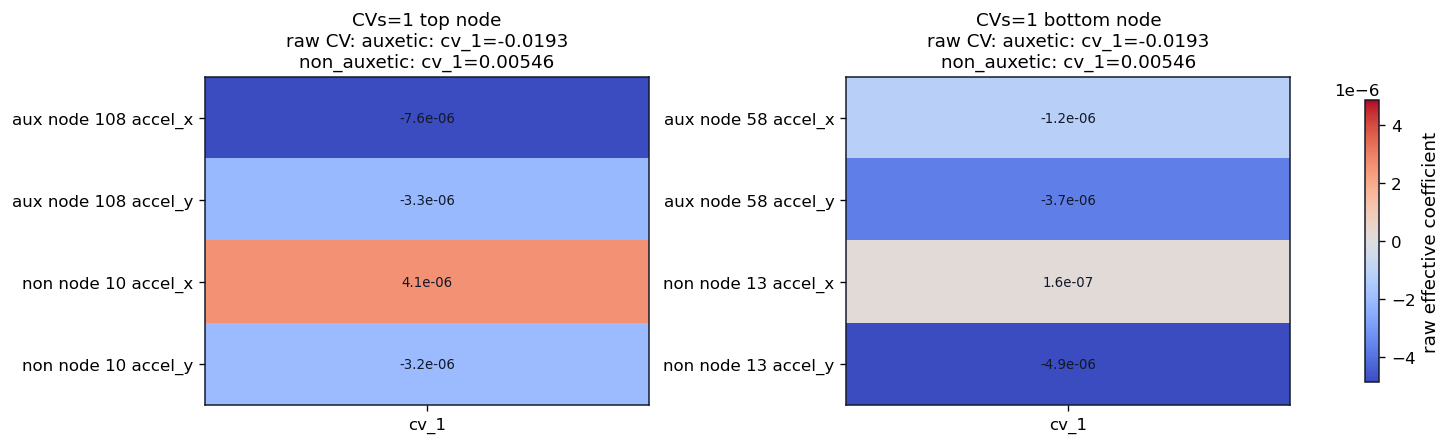

Global decoder selected-node acceleration and velocity check


,CVs,selection,node_label,node_idx,probe_t,raw_y,current_velocity_y,predicted_accel_y,cv_branch_only_accel_y,decoder_matrix_kind,linearized_cv_term_y,decoded_next_velocity_y,true_next_velocity_y
0,1,auxetic,top_node,108,66,6.65654,-0.00022,0.0,0.0,fixed raw W,0.0,-0.00022,-0.00023
1,1,auxetic,bottom_node,58,66,-6.72243,0.00043,0.0,0.0,fixed raw W,0.0,0.00043,0.00042
2,1,non_auxetic,top_node,10,64,6.57491,0.00020,0.0,-0.0,fixed raw W,-0.0,0.00020,0.00021
3,1,non_auxetic,bottom_node,13,64,-6.52495,-0.00021,0.0,-0.0,fixed raw W,-0.0,-0.00021,-0.00020


In [10]:
# CV=1 vs CV=2: global CV decoder matrix, Chignolin-style.

selected_contexts = sorted([ctx for ctx in run_contexts if int(ctx['CVs']) in (1, 2)], key=lambda item: int(item['CVs']))
if not selected_contexts:
    raise RuntimeError('No CVs=1 or CVs=2 contexts found. Run the training/config cell with cv_counts including 1 and 2.')

required = {'comparison_cases', 'model', 'cfg_loaded', 'device', 'base_cv_cols'}
missing = {int(ctx['CVs']): sorted(required - set(ctx)) for ctx in selected_contexts if required - set(ctx)}
if missing:
    raise RuntimeError(f'Run the side-by-side decoder diagnostic cell before this cell. Missing context keys: {missing}')


def direct_cv_and_accel_for_ctx(ctx_local, graph):
    model_local = ctx_local['model']
    with torch.no_grad():
        cv, pred_accel = model_local.predict_motion_from_cv(
            graph.to(ctx_local['device']),
            include_output_offset=True,
            is_training=False,
        )
    return cv.detach().cpu().numpy().reshape(-1), pred_accel.detach().cpu().numpy()


def cv_branch_raw_accel_and_jacobian_for_nodes(ctx_local, graph, node_indices):
    model_local = ctx_local['model']
    cfg_local = ctx_local['cfg_loaded']
    norm_graph = model_local.normalize_graph(graph.to(ctx_local['device']), is_training=False)
    cv_base, aux = model_local.encode_cv_from_normalized(norm_graph)
    cv0 = cv_base.detach().clone().requires_grad_(True)
    node_indices_t = torch.as_tensor(node_indices, dtype=torch.long, device=cv0.device)
    output_mean_t = model_local.output_normalizer._mean().reshape(-1)[: cfg_local.pos_dim] if getattr(model_local, 'use_normalization', True) else torch.zeros(cfg_local.pos_dim, device=cv0.device, dtype=cv0.dtype)
    output_std_t = model_local.output_normalizer._std_with_epsilon().reshape(-1)[: cfg_local.pos_dim] if getattr(model_local, 'use_normalization', True) else torch.ones(cfg_local.pos_dim, device=cv0.device, dtype=cv0.dtype)

    def raw_accel_from_cv(cv_value):
        pred_norm = model_local.decode_cv_from_normalized(
            norm_graph,
            cv_value,
            aux=aux,
            zero_local_skip=True,
        )[node_indices_t]
        return pred_norm * output_std_t.reshape(1, -1) + output_mean_t.reshape(1, -1)

    pred_raw = raw_accel_from_cv(cv0) - raw_accel_from_cv(torch.zeros_like(cv0))
    jac = torch.autograd.functional.jacobian(raw_accel_from_cv, cv0, vectorize=False)
    jac = jac[:, :, 0, :].detach().cpu().numpy()
    return cv0.detach().cpu().numpy().reshape(-1), pred_raw.detach().cpu().numpy(), jac

matrix_rows = []
cv_rows = []
node_rows = []
for ctx in selected_contexts:
    model_local = ctx['model']
    cfg_local = ctx['cfg_loaded']
    decoder_matrix_kind = 'CV-branch effective matrix' if (getattr(model_local, 'global_decoder_local_skip', False) or not isinstance(getattr(model_local, 'global_cv_head', None), torch.nn.Linear)) else 'fixed raw W'

    for case in ctx['comparison_cases']:
        selection = 'auxetic' if case['selection'] == 'auxetic' else 'non_auxetic'
        sim = {'train': ctx['train_data'], 'val': ctx['val_data'], 'test': ctx['test_data']}[case['traj']['split']][int(case['traj']['sim_idx'])]
        probe_t = int(case['probe_t'])
        graph = build_graph(frame_window(sim, probe_t, cfg_local, ctx['device']), node_features=cfg_local.node_features).to(ctx['device'])
        pos_raw = graph.x[:, : cfg_local.pos_dim].detach().cpu().numpy()
        cv_values, pred_accel = direct_cv_and_accel_for_ctx(ctx, graph)
        current_vel = pos_raw - sim[probe_t - 1].x[:, : cfg_local.pos_dim].detach().cpu().numpy()
        decoded_next_vel = current_vel + pred_accel[:, : cfg_local.pos_dim]
        true_next_vel = sim[probe_t + 1].x[:, : cfg_local.pos_dim].detach().cpu().numpy() - pos_raw
        selected_nodes = {'top_node': int(np.argmax(pos_raw[:, 1])), 'bottom_node': int(np.argmin(pos_raw[:, 1]))}
        node_order = list(selected_nodes.values())
        _, cv_branch_nodes, J_nodes = cv_branch_raw_accel_and_jacobian_for_nodes(ctx, graph, node_order)
        jac_by_node = {node_idx: J_nodes[i] for i, node_idx in enumerate(node_order)}
        cv_branch_by_node = {node_idx: cv_branch_nodes[i] for i, node_idx in enumerate(node_order)}

        for cv_idx, col in enumerate(ctx['base_cv_cols']):
            cv_rows.append({'CVs': int(ctx['CVs']), 'selection': selection, 'probe_t': probe_t, 'cv': col, 'raw_cv_value': float(cv_values[cv_idx])})

        for node_label, node_idx in selected_nodes.items():
            J_node = jac_by_node[node_idx]
            linearized_cv_term = J_node @ cv_values
            node_rows.append({
                'CVs': int(ctx['CVs']),
                'selection': selection,
                'node_label': node_label,
                'node_idx': node_idx,
                'probe_t': probe_t,
                'raw_y': float(pos_raw[node_idx, 1]),
                'current_velocity_y': float(current_vel[node_idx, 1]),
                'predicted_accel_y': float(pred_accel[node_idx, 1]),
                'cv_branch_only_accel_y': float(cv_branch_by_node[node_idx][1]),
                'decoder_matrix_kind': decoder_matrix_kind,
                'linearized_cv_term_y': float(linearized_cv_term[1]),
                'decoded_next_velocity_y': float(decoded_next_vel[node_idx, 1]),
                'true_next_velocity_y': float(true_next_vel[node_idx, 1]),
            })
            for axis_idx, axis_name in enumerate(['accel_x', 'accel_y'][: cfg_local.pos_dim]):
                row = {'CVs': int(ctx['CVs']), 'selection': selection, 'node_label': node_label, 'node_idx': node_idx, 'output': axis_name}
                for cv_idx, col in enumerate(ctx['base_cv_cols']):
                    row[col] = float(J_node[axis_idx, cv_idx])
                row['matrix_kind'] = decoder_matrix_kind
                matrix_rows.append(row)

cv_value_df = pd.DataFrame(cv_rows)
selected_w_df = pd.DataFrame(matrix_rows)
node_summary_df = pd.DataFrame(node_rows)

paper_caption('Global decoder: raw CV values at the probe frame')
display(cv_value_df.round(6))

paper_caption('CV branch only: selected-node effective matrix, raw d(acceleration) / d(raw CV)')
fig, axes = plt.subplots(len(selected_contexts), 2, figsize=(12.0, 3.6 * len(selected_contexts)), squeeze=False, constrained_layout=True)
last_im = None
for row_idx, ctx in enumerate(selected_contexts):
    for col_idx, node_label in enumerate(['top_node', 'bottom_node']):
        ax = axes[row_idx, col_idx]
        rows = []
        labels = []
        for selection in ['auxetic', 'non_auxetic']:
            sub = selected_w_df[(selected_w_df['CVs'] == int(ctx['CVs'])) & (selected_w_df['selection'] == selection) & (selected_w_df['node_label'] == node_label)].set_index('output')
            mat = sub.loc[['accel_x', 'accel_y'][: ctx['cfg_loaded'].pos_dim], ctx['base_cv_cols']]
            rows.extend(mat.to_numpy(dtype=float))
            node_idx = int(sub['node_idx'].iloc[0])
            prefix = 'aux' if selection == 'auxetic' else 'non'
            labels.extend([f'{prefix} node {node_idx} accel_x', f'{prefix} node {node_idx} accel_y'][: ctx['cfg_loaded'].pos_dim])
        value_mat = np.vstack(rows)
        max_abs = max(float(np.max(np.abs(value_mat))), 1e-12)
        last_im = ax.imshow(value_mat, cmap='coolwarm', vmin=-max_abs, vmax=max_abs, aspect='auto')
        ax.set_xticks(np.arange(len(ctx['base_cv_cols'])))
        ax.set_xticklabels(ctx['base_cv_cols'])
        ax.set_yticks(np.arange(len(labels)))
        ax.set_yticklabels(labels)
        cv_sub = cv_value_df[cv_value_df['CVs'] == int(ctx['CVs'])].pivot(index='selection', columns='cv', values='raw_cv_value').reindex(['auxetic', 'non_auxetic']).loc[:, ctx['base_cv_cols']]
        cv_text = '\n'.join(f"{sel}: " + ', '.join(f"{c}={cv_sub.loc[sel, c]:.3g}" for c in ctx['base_cv_cols']) for sel in cv_sub.index)
        ax.set_title(f"CVs={ctx['CVs']} {node_label.replace('_', ' ')}\nraw CV: {cv_text}")
        for r in range(value_mat.shape[0]):
            for c in range(value_mat.shape[1]):
                ax.text(c, r, f'{value_mat[r, c]:.2g}', ha='center', va='center', color=PAPER_COLORS['ink'], fontsize=8)
if last_im is not None:
    fig.colorbar(last_im, ax=axes.ravel().tolist(), location='right', shrink=0.86, pad=0.04, label='raw effective coefficient')
plt.show()

paper_caption('Global decoder selected-node acceleration and velocity check')
display(node_summary_df.round(6))


One-frame raw CV values used for CV-branch rendering


,CVs,selection,t,linearized_cv_term_mse,matrix_kind,cv_1
0,1,auxetic,66,0.0,fixed raw W,-0.019254
1,1,non_auxetic,64,0.0,fixed raw W,0.005459


One-frame CV branch field: node color is CV-branch accel_y, arrows are CV-branch acceleration


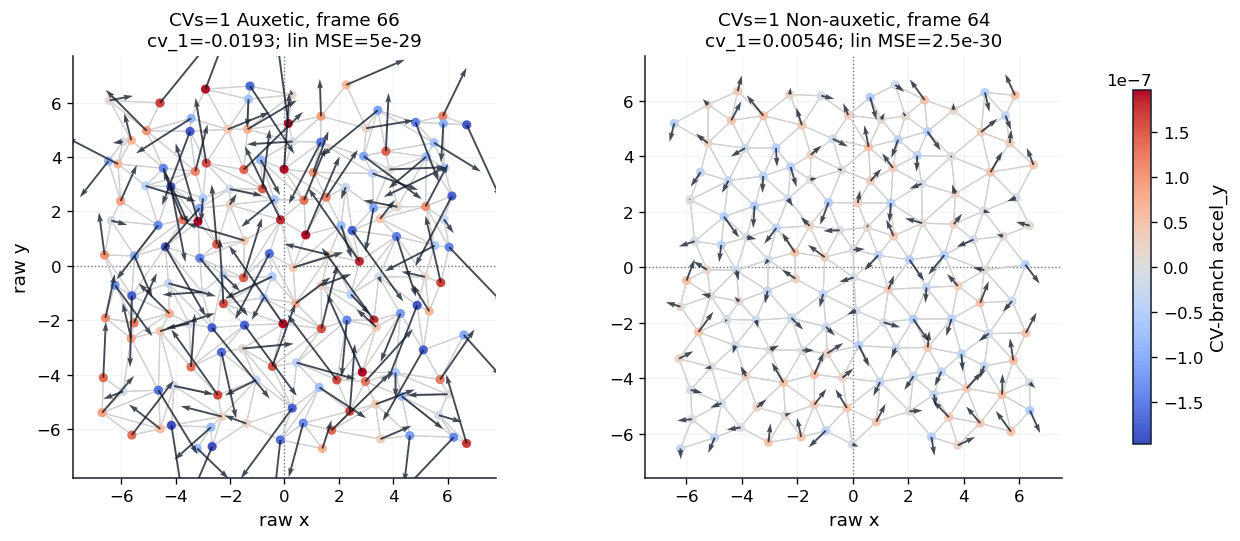

In [11]:
# Global decoder on one frame: render the CV branch only over the elastic network.

selected_contexts = sorted([ctx for ctx in run_contexts if int(ctx['CVs']) in (1, 2)], key=lambda item: int(item['CVs']))
if not selected_contexts:
    raise RuntimeError('No CVs=1 or CVs=2 contexts found. Run the training/config cell with cv_counts including 1 and 2.')

required = {'comparison_cases', 'model', 'cfg_loaded', 'device', 'base_cv_cols'}
missing = {int(ctx['CVs']): sorted(required - set(ctx)) for ctx in selected_contexts if required - set(ctx)}
if missing:
    raise RuntimeError(f'Run the side-by-side decoder diagnostic cell before this cell. Missing context keys: {missing}')


def global_cv_branch_and_jacobian(ctx_local, graph):
    model_local = ctx_local['model']
    cfg_local = ctx_local['cfg_loaded']
    norm_graph = model_local.normalize_graph(graph.to(ctx_local['device']), is_training=False)
    cv_base, aux = model_local.encode_cv_from_normalized(norm_graph)
    cv0 = cv_base.detach().clone().requires_grad_(True)
    output_mean_t = model_local.output_normalizer._mean().reshape(-1)[: cfg_local.pos_dim] if getattr(model_local, 'use_normalization', True) else torch.zeros(cfg_local.pos_dim, device=cv0.device, dtype=cv0.dtype)
    output_std_t = model_local.output_normalizer._std_with_epsilon().reshape(-1)[: cfg_local.pos_dim] if getattr(model_local, 'use_normalization', True) else torch.ones(cfg_local.pos_dim, device=cv0.device, dtype=cv0.dtype)

    def raw_accel_from_cv(cv_value):
        pred_norm = model_local.decode_cv_from_normalized(
            norm_graph,
            cv_value,
            aux=aux,
            zero_local_skip=True,
        )
        return pred_norm * output_std_t.reshape(1, -1) + output_mean_t.reshape(1, -1)

    pred_accel = raw_accel_from_cv(cv0) - raw_accel_from_cv(torch.zeros_like(cv0))
    jac = torch.autograd.functional.jacobian(raw_accel_from_cv, cv0, vectorize=False)[:, :, 0, :]
    return cv0.detach().cpu().numpy().reshape(-1), pred_accel.detach().cpu().numpy(), jac.detach().cpu().numpy()


render_rows = []
render_cases = []
for ctx in selected_contexts:
    cfg_local = ctx['cfg_loaded']
    for case in ctx['comparison_cases']:
        selection = 'auxetic' if case['selection'] == 'auxetic' else 'non_auxetic'
        sim = {'train': ctx['train_data'], 'val': ctx['val_data'], 'test': ctx['test_data']}[case['traj']['split']][int(case['traj']['sim_idx'])]
        t = int(case['probe_t'])
        graph = build_graph(frame_window(sim, t, cfg_local, ctx['device']), node_features=cfg_local.node_features).to(ctx['device'])
        pos_raw = graph.x[:, : cfg_local.pos_dim].detach().cpu().numpy()
        edges = visible_edges(graph, pos_raw)
        cv, cv_branch_accel, jac_raw = global_cv_branch_and_jacobian(ctx, graph)
        cv_contrib = np.einsum('nac,c->na', jac_raw[: pos_raw.shape[0]], cv)
        linearized_mse = float(np.mean((cv_contrib - cv_branch_accel[:, : cfg_local.pos_dim]) ** 2))
        render_cases.append({
            'ctx': ctx,
            'selection': selection,
            't': t,
            'pos': pos_raw,
            'edges': edges,
            'cv': cv,
            'cv_contrib': cv_contrib,
            'cv_branch_accel': cv_branch_accel[:, : cfg_local.pos_dim],
            'linearized_cv_term': cv_contrib,
            'linearized_mse': linearized_mse,
            'matrix_kind': 'fixed raw W' if (not getattr(ctx['model'], 'global_decoder_local_skip', False) and isinstance(getattr(ctx['model'], 'global_cv_head', None), torch.nn.Linear)) else 'CV-branch effective matrix',
        })
        row = {'CVs': int(ctx['CVs']), 'selection': selection, 't': t, 'linearized_cv_term_mse': linearized_mse, 'matrix_kind': render_cases[-1]['matrix_kind']}
        for cv_idx, col in enumerate(ctx['base_cv_cols']):
            row[col] = float(cv[cv_idx])
        render_rows.append(row)

render_df = pd.DataFrame(render_rows)
paper_caption('One-frame raw CV values used for CV-branch rendering')
display(render_df.round(6))

all_pos = np.vstack([item['pos'][:, :2] for item in render_cases])
all_vec = np.vstack([item['cv_branch_accel'][:, :2] for item in render_cases])
vector_scale = arrow_scale(all_pos, all_vec, target_fraction=0.26)
color_values = np.concatenate([item['cv_branch_accel'][:, 1] for item in render_cases])
color_lim = max(float(np.max(np.abs(color_values))), 1e-12)

paper_caption('One-frame CV branch field: node color is CV-branch accel_y, arrows are CV-branch acceleration')
fig, axes = plt.subplots(len(selected_contexts), 2, figsize=(10.8, 4.4 * len(selected_contexts)), squeeze=False, constrained_layout=True)
last_scatter = None
case_lookup = {(int(item['ctx']['CVs']), item['selection']): item for item in render_cases}
for row_idx, ctx in enumerate(selected_contexts):
    for col_idx, selection in enumerate(['auxetic', 'non_auxetic']):
        ax = axes[row_idx, col_idx]
        item = case_lookup[(int(ctx['CVs']), selection)]
        pos = item['pos']
        accel = item['cv_branch_accel']
        for src, dst in item['edges']:
            ax.plot([pos[src, 0], pos[dst, 0]], [pos[src, 1], pos[dst, 1]], color='0.82', lw=0.7, zorder=1)
        last_scatter = ax.scatter(pos[:, 0], pos[:, 1], c=accel[:, 1], s=20, cmap='coolwarm', vmin=-color_lim, vmax=color_lim, zorder=2)
        v = accel[:, :2] * vector_scale
        ax.quiver(pos[:, 0], pos[:, 1], v[:, 0], v[:, 1], angles='xy', scale_units='xy', scale=1.0, color=PAPER_COLORS['ink'], width=0.0045, alpha=0.78, zorder=3)
        ax.axhline(0.0, color='0.35', lw=0.8, ls=':', zorder=0)
        ax.axvline(0.0, color='0.35', lw=0.8, ls=':', zorder=0)
        ax.set_aspect('equal', adjustable='box')
        set_tight_data_limits(ax, pos[:, 0], pos[:, 1], pad_fraction=0.08)
        cv_text = ', '.join(f"{col}={item['cv'][i]:.3g}" for i, col in enumerate(ctx['base_cv_cols']))
        title = 'Auxetic' if selection == 'auxetic' else 'Non-auxetic'
        ax.set_title(f"CVs={ctx['CVs']} {title}, frame {item['t']}\n{cv_text}; lin MSE={item['linearized_mse']:.2g}")
        style_axes(ax, xlabel='raw x', ylabel='raw y' if col_idx == 0 else None)
if last_scatter is not None:
    fig.colorbar(last_scatter, ax=axes.ravel().tolist(), location='right', shrink=0.84, pad=0.04, label='CV-branch accel_y')
plt.show()


Middle-window selected-node integrated y behavior


,CVs,selection,node_label,node_idx,start_t,end_t,final_cum_predicted_accel_y,final_cum_decoded_y_displacement,final_cum_true_y_displacement
0,1,auxetic,top_node,108,27,106,0.000007,-0.017943,-0.01794
1,1,auxetic,bottom_node,58,27,106,0.000008,0.033938,0.03395
2,1,non_auxetic,top_node,10,26,103,0.000001,0.016401,0.01640
3,1,non_auxetic,bottom_node,13,26,103,0.000000,-0.016070,-0.01606


Middle-window top node: acceleration integration into velocity


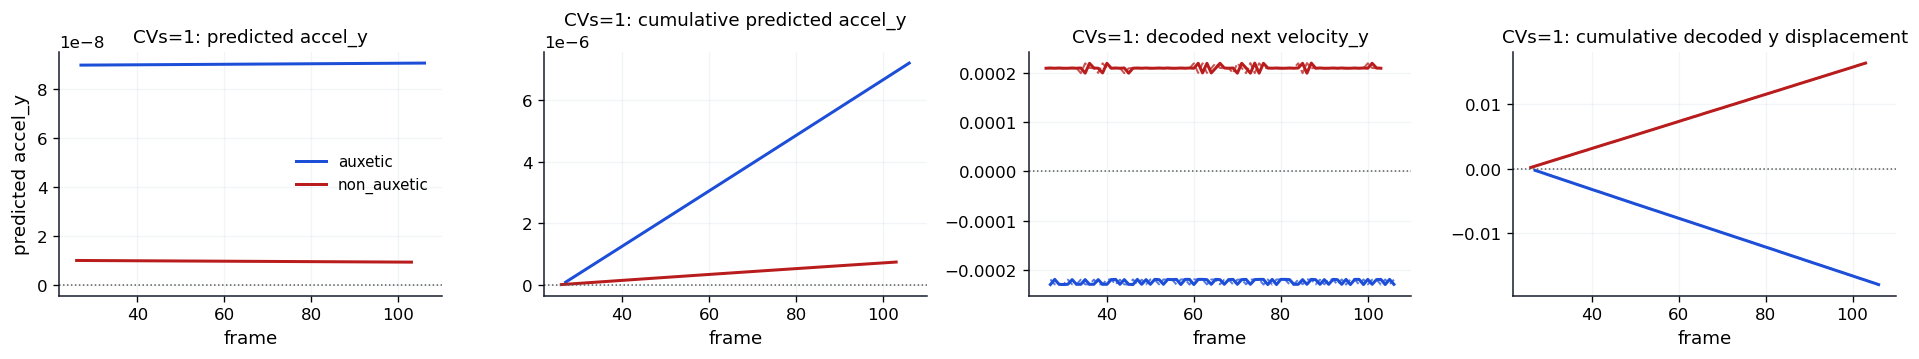

Middle-window bottom node: acceleration integration into velocity


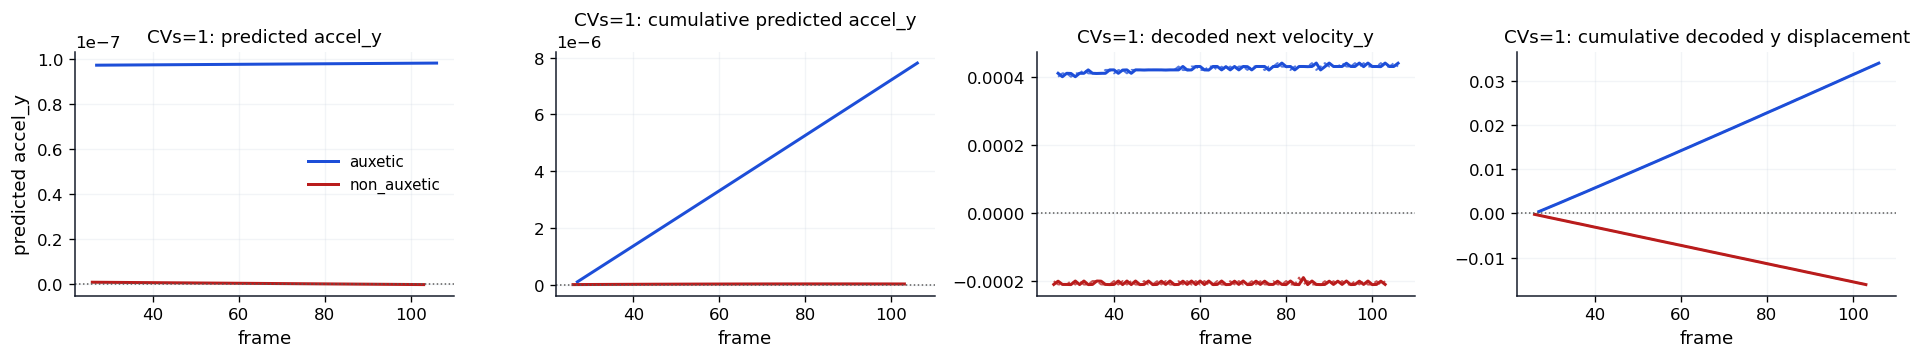

In [12]:
# CV=1 vs CV=2: integrate acceleration to understand velocity and y-motion.

selected_contexts = sorted([ctx for ctx in run_contexts if int(ctx['CVs']) in (1, 2)], key=lambda item: int(item['CVs']))
if not selected_contexts:
    raise RuntimeError('No CVs=1 or CVs=2 contexts found. Run the training/config cell with cv_counts including 1 and 2.')

required = {'comparison_cases', 'model', 'cfg_loaded', 'device', 'base_cv_cols'}
missing = {int(ctx['CVs']): sorted(required - set(ctx)) for ctx in selected_contexts if required - set(ctx)}
if missing:
    raise RuntimeError(f'Run the side-by-side decoder diagnostic cell before this cell. Missing context keys: {missing}')


def direct_cv_and_accel_for_ctx(ctx_local, graph):
    model_local = ctx_local['model']
    if getattr(model_local, 'prediction_target', 'acceleration') != 'acceleration':
        raise RuntimeError(f"This cell expects acceleration models, but CVs={ctx_local['CVs']} predicts {model_local.prediction_target!r}.")
    with torch.no_grad():
        cv, pred_accel = model_local.predict_motion_from_cv(
            graph.to(ctx_local['device']),
            include_output_offset=True,
            is_training=False,
        )
    return cv.detach().cpu().numpy().reshape(-1), pred_accel.detach().cpu().numpy()


behavior_rows = []
summary_rows = []
for ctx in selected_contexts:
    cfg_local = ctx['cfg_loaded']
    for case in ctx['comparison_cases']:
        selection = 'auxetic' if case['selection'] == 'auxetic' else 'non_auxetic'
        sim = {'train': ctx['train_data'], 'val': ctx['val_data'], 'test': ctx['test_data']}[case['traj']['split']][int(case['traj']['sim_idx'])]
        start_t = int(case['start_t'])
        end_t = int(case['end_t'])
        probe_t = int(case['probe_t'])
        probe_graph = build_graph(frame_window(sim, probe_t, cfg_local, ctx['device']), node_features=cfg_local.node_features).to(ctx['device'])
        probe_pos = probe_graph.x[:, : cfg_local.pos_dim].detach().cpu().numpy()
        selected_nodes = {'top_node': int(np.argmax(probe_pos[:, 1])), 'bottom_node': int(np.argmin(probe_pos[:, 1]))}

        running = {
            label: {'cum_pred_accel_y': 0.0, 'cum_decoded_dy': 0.0, 'cum_true_dy': 0.0}
            for label in selected_nodes
        }
        for t in range(start_t, end_t + 1):
            graph = build_graph(frame_window(sim, t, cfg_local, ctx['device']), node_features=cfg_local.node_features).to(ctx['device'])
            pos_t = graph.x[:, : cfg_local.pos_dim].detach().cpu().numpy()
            current_vel = pos_t - sim[t - 1].x[:, : cfg_local.pos_dim].detach().cpu().numpy()
            true_next_pos = sim[t + 1].x[:, : cfg_local.pos_dim].detach().cpu().numpy()
            true_next_vel = true_next_pos - pos_t
            _, pred_accel = direct_cv_and_accel_for_ctx(ctx, graph)
            decoded_next_vel = current_vel + pred_accel[:, : cfg_local.pos_dim]

            for node_label, node_idx in selected_nodes.items():
                running[node_label]['cum_pred_accel_y'] += float(pred_accel[node_idx, 1])
                running[node_label]['cum_decoded_dy'] += float(decoded_next_vel[node_idx, 1])
                running[node_label]['cum_true_dy'] += float(true_next_vel[node_idx, 1])
                behavior_rows.append({
                    'CVs': int(ctx['CVs']),
                    'selection': selection,
                    'node_label': node_label,
                    'node_idx': node_idx,
                    't': int(t),
                    'predicted_accel_y': float(pred_accel[node_idx, 1]),
                    'cum_predicted_accel_y': running[node_label]['cum_pred_accel_y'],
                    'current_velocity_y': float(current_vel[node_idx, 1]),
                    'decoded_next_velocity_y': float(decoded_next_vel[node_idx, 1]),
                    'true_next_velocity_y': float(true_next_vel[node_idx, 1]),
                    'cum_decoded_y_displacement': running[node_label]['cum_decoded_dy'],
                    'cum_true_y_displacement': running[node_label]['cum_true_dy'],
                })
        for node_label, node_idx in selected_nodes.items():
            summary_rows.append({
                'CVs': int(ctx['CVs']),
                'selection': selection,
                'node_label': node_label,
                'node_idx': node_idx,
                'start_t': start_t,
                'end_t': end_t,
                'final_cum_predicted_accel_y': running[node_label]['cum_pred_accel_y'],
                'final_cum_decoded_y_displacement': running[node_label]['cum_decoded_dy'],
                'final_cum_true_y_displacement': running[node_label]['cum_true_dy'],
            })

behavior_df = pd.DataFrame(behavior_rows)
behavior_summary_df = pd.DataFrame(summary_rows)
paper_caption('Middle-window selected-node integrated y behavior')
display(behavior_summary_df.round(6))

panels = [
    ('predicted_accel_y', 'predicted accel_y'),
    ('cum_predicted_accel_y', 'cumulative predicted accel_y'),
    ('decoded_next_velocity_y', 'decoded next velocity_y'),
    ('cum_decoded_y_displacement', 'cumulative decoded y displacement'),
]
for node_label in ['top_node', 'bottom_node']:
    paper_caption(f'Middle-window {node_label.replace("_", " ")}: acceleration integration into velocity')
    fig, axes = plt.subplots(len(selected_contexts), len(panels), figsize=(4.0 * len(panels), 3.1 * len(selected_contexts)), sharey=False, squeeze=False)
    for row_idx, ctx in enumerate(selected_contexts):
        for col_idx, (metric, title) in enumerate(panels):
            ax = axes[row_idx, col_idx]
            for selection, color in [('auxetic', PAPER_COLORS['blue']), ('non_auxetic', PAPER_COLORS['red'])]:
                sub = behavior_df[(behavior_df['CVs'] == int(ctx['CVs'])) & (behavior_df['selection'] == selection) & (behavior_df['node_label'] == node_label)]
                ax.plot(sub['t'], sub[metric], color=color, lw=1.8, label=selection)
                if metric == 'decoded_next_velocity_y':
                    ax.plot(sub['t'], sub['true_next_velocity_y'], color=color, lw=1.2, ls='--', alpha=0.75)
                if metric == 'cum_decoded_y_displacement':
                    ax.plot(sub['t'], sub['cum_true_y_displacement'], color=color, lw=1.2, ls='--', alpha=0.75)
            ax.axhline(0.0, color='0.35', lw=0.9, ls=':')
            ax.set_title(f"CVs={ctx['CVs']}: {title}")
            ylabel = title if col_idx == 0 else None
            style_axes(ax, xlabel='frame', ylabel=ylabel, legend=(row_idx == 0 and col_idx == 0))
    plt.tight_layout()
    plt.show()


In [13]:
# Pyramid compression attention maps back to original nodes.

required = {'model', 'cfg_loaded', 'device', 'test_data'}
missing = [ctx['CVs'] for ctx in run_contexts if not required.issubset(ctx)]
if missing:
    raise RuntimeError(f'Run the model-loading cell before this cell. Missing context for CV counts: {missing}')

attention_context = run_contexts[0]
attention_split = 'test'
attention_sim_idx = 0
attention_frame_fraction = 0.50
max_tokens_per_layer = 6


def attention_sim_for_context(ctx, split_name, sim_idx):
    sims = {'train': ctx['train_data'], 'val': ctx['val_data'], 'test': ctx['test_data']}[split_name]
    if not (0 <= int(sim_idx) < len(sims)):
        raise IndexError(f'{split_name} sim_idx={sim_idx} outside 0..{len(sims)-1}')
    return sims[int(sim_idx)]


def pyramid_attention_to_nodes(ctx, sim, frame_fraction=0.50):
    cfg_local = ctx['cfg_loaded']
    device_local = ctx['device']
    model_local = ctx['model']
    t_min = int(cfg_local.history)
    t_max = max(t_min, len(sim) - 2)
    t = int(round(t_min + float(frame_fraction) * (t_max - t_min)))
    t = min(max(t, t_min), t_max)

    raw_graph = sim[t].clone().cpu()
    if not (hasattr(model_local, 'adapter') and hasattr(model_local, 'core')):
        return raw_graph, t, [], np.asarray([])
    graph = build_graph(frame_window(sim, t, cfg_local, device_local), node_features=cfg_local.node_features).to(device_local)
    was_training = model_local.training
    model_local.eval()
    with torch.no_grad():
        norm_graph = model_local.normalize_graph(graph, is_training=False)
        core_input = model_local.adapter.build_core_input(norm_graph)
        model_local.core.encode(core_input, capture_attention=True)
    model_local.train(was_training)

    pyramid_attn = model_local.core.last_pyramid_attn
    if not pyramid_attn:
        raise RuntimeError('No pyramid attention was captured. Re-run imports after updating cv_core.py.')

    n_nodes = int(graph.x.size(0))
    composed_layers = []
    running = None
    for layer_idx, attn in enumerate(pyramid_attn, start=1):
        # attn: [batch, heads, compressed_tokens, source_tokens]
        A = attn[0].mean(dim=0).detach().cpu().numpy()
        if running is None:
            node_map = A[:, :n_nodes]
        else:
            node_map = A @ running
        row_sum = np.maximum(node_map.sum(axis=1, keepdims=True), 1e-12)
        node_map = node_map / row_sum
        composed_layers.append({'name': f'pyramid layer {layer_idx}', 'node_map': node_map})
        running = node_map

    cv_attn = model_local.core.last_cv_attn
    if cv_attn is not None and running is not None:
        # last_cv_attn: [batch, heads, CVs, final_pyramid_tokens]
        A_cv = cv_attn[0].mean(dim=0).detach().cpu().numpy()
        cv_map = A_cv @ running
        cv_map = cv_map / np.maximum(cv_map.sum(axis=1, keepdims=True), 1e-12)
        composed_layers.append({'name': 'CV attention layer', 'node_map': cv_map})

    return raw_graph, t, composed_layers, model_local.core.last_cv.detach().cpu().numpy().reshape(-1)


def token_locality_scores(node_map):
    arr = np.asarray(node_map, dtype=float)
    p = arr / np.maximum(arr.sum(axis=1, keepdims=True), 1e-12)
    entropy = -np.sum(p * np.log(np.maximum(p, 1e-12)), axis=1)
    peak = np.max(p, axis=1)
    return peak, entropy


def draw_attention_token_graph(ax, graph_cpu, importance, title, norm):
    # Render raw attention mass, not per-panel normalized values. The shared
    # norm makes it possible to see whether a token is genuinely localized.
    values = np.asarray(importance, dtype=float).reshape(-1)
    cmap = plt.get_cmap('magma')
    node_rgba = [cmap(norm(float(values[int(node_idx)]))) for node_idx in range(len(values))]
    G = pyg_to_networkx(graph_cpu, collapse_undirected=True, pos_slice=(0, 2))
    draw_graph(
        G,
        periodic_edges=False,
        node_color=node_rgba,
        node_size=24,
        show_labels=False,
        ax=ax,
        show=False,
    )
    ax.set_title(title)
    ax.set_aspect('equal')
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    return sm


sim = attention_sim_for_context(attention_context, attention_split, attention_sim_idx)
graph_cpu, frame_t, attention_layers, raw_cv = pyramid_attention_to_nodes(attention_context, sim, attention_frame_fraction)

if not attention_layers:
    paper_caption(
        f"CVs={attention_context['CVs']}: this model does not expose pyramid attention maps."
    )
else:
    paper_caption(
        f"CVs={attention_context['CVs']}: pyramid compression attention mapped to original nodes\n"
        f"{attention_split} sim {attention_sim_idx}, frame {frame_t}, raw CV={np.array2string(raw_cv, precision=4, separator=', ')}"
    )

for layer in attention_layers:
    node_map = layer['node_map']
    peak, entropy = token_locality_scores(node_map)
    chosen = np.argsort(-peak)[: min(max_tokens_per_layer, node_map.shape[0])]

    # A compression layer is a whole set of output tokens. Each row below is
    # one compressed token's attention distribution over original nodes.
    mean_over_tokens = np.mean(node_map, axis=0)
    max_over_tokens = np.max(node_map, axis=0)
    vmax = float(np.nanmax(node_map))
    norm = plt.Normalize(vmin=0.0, vmax=max(vmax, 1e-12))

    ncols = len(chosen) + 2
    fig, axes = plt.subplots(1, ncols, figsize=(3.1 * ncols, 3.2), squeeze=False)
    last_scatter = draw_attention_token_graph(
        axes[0, 0],
        graph_cpu,
        mean_over_tokens,
        f"{layer['name']}\nmean over tokens",
        norm,
    )
    draw_attention_token_graph(
        axes[0, 1],
        graph_cpu,
        max_over_tokens,
        f"{layer['name']}\nmax over tokens",
        norm,
    )
    for ax, token_idx in zip(axes[0, 2:], chosen):
        draw_attention_token_graph(
            ax,
            graph_cpu,
            node_map[int(token_idx)],
            f"{layer['name']} token {int(token_idx)}\npeak={peak[int(token_idx)]:.4f}, H={entropy[int(token_idx)]:.2f}",
            norm,
        )
    fig.colorbar(last_scatter, ax=axes.ravel().tolist(), location='right', shrink=0.78, pad=0.02, label='raw attention mass')
    plt.tight_layout()
    plt.show()
    print(layer['name'], 'tokens=', node_map.shape[0], 'nodes=', node_map.shape[1], 'raw attention min/mean/max=', float(np.min(node_map)), float(np.mean(node_map)), float(np.max(node_map)))


CVs=1: this model does not expose pyramid attention maps.
